#Decision Fusion For Cyber-Physical Threat Detection

**The purpose of decision fusion is to provide a holistic view on detecting Advanced Persistent Threats (APT) attack behaviours that leverages Living off the Land (LOTL) technqiues to induce cyber-physical attacks in industrial settings.**

**This notebook demonstrates the process of creating a Two-Level Decision Fusion for detecting a multi-stage attack simulated on a Digital Twin-based testbed on 9 May 2025. During the simulation, Network, process and host data are collected and analysed for threat detection.**

#Objective of This Notebook

**The goal of this notebook is to show the process of decision fusion for cross-domain anomalies, including**

*   **1st Level** - **OT fusion** (OPC UA Network Anomaly + Process Anomaly + Process Alarm)
*   **2nd Level** - **IT/OT fusion** (the output of the OT fusion + Host Anomaly)


*Note: Separate notesbooks in the Github provides information about how the anomalies in cross-domain (host, network, process) are being processed and detected.*

## Background

A multi-stage cyber-physical attack simulation was conducted on 9 May 2025, between 14:34 and 17:02 (UK local time), using a Digital Twin-based testbed replicating a sorting process controlled within [**Siemens NX Mechatronic Concept Designer**](https://plm.sw.siemens.com/en-US/nx/cad-online/automation/mechatronic-design/), controlled by virtual PLC in [**Siemens PLCSim Advanced**](https://www.siemens.com/global/en/products/automation/systems/industrial/plc/s7-plcsim-advanced.html). The project files (i.e. PLC logic of the sorting process) is prepared in [**Siemens TIA Portal**](https://www.siemens.com/global/en/products/automation/industry-software/automation-software/tia-portal.html).

In addition, to simulate real-world adversarial behaviours targeting Cyber Physical Systems and Industrial Control Systems, the testbed was integrated with OPC UA clients:

*   [**Ignition Human Machine Interface (HMI)**](https://inductiveautomation.com/) - a common SCADA/HMI software supporting industrial automation
*   [**UA Expert**](https://www.unified-automation.com/) -  a common diagnostic tool for OPC UA connection


The starting step of the 5-step attack chain is shown below (UK local time | UTC + 1 hour)

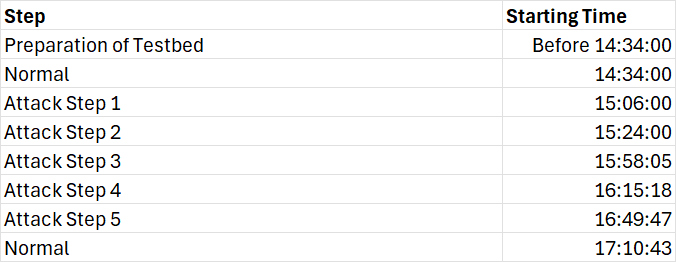

All the steps are simulated using **Living off the Land techniques** using native Windows binaries and legitimate tools already presence in the victim environment, including PowerShell-based reconnaissance, credential abuse, graphical user interface, and lateral movement. For details of the attacks, please refer to paper.

Out of the five attack steps, **Step 3** and **Step 5** involved the use of OPC UA clients to carry out manipulations of the physical process on Siemens NX:

*  **Step 3**: Issued unauthorized commands through [**Ignition Human Machine Interface (HMI)**](https://inductiveautomation.com/) by probing the the physical process on [**Siemens NX Mechatronic Concept Designer**](https://plm.sw.siemens.com/en-US/nx/cad-online/automation/mechatronic-design/) via Remote Desktop Protocol (RDP) session. During Step 3, we also simulated attacker suppressed the alarms triggered by [**Ignition Human Machine Interface (HMI)**](https://inductiveautomation.com/)
*   **Step 5**: Executed unauthorized OPC UA write requests from [**UA Expert**](https://www.unified-automation.com/) to manipulate the physical process on [**Siemens NX Mechatronic Concept Designer**](https://plm.sw.siemens.com/en-US/nx/cad-online/automation/mechatronic-design/) via RDP session.

These two steps are expected to exhibit anomalous actuator behaviours detectable in the process data and OPC UA network data. For instance, the conveyor speed is too high/low, the robot gripper arm is not rotated or positioned as expected.



In contrast, Steps 1, 2, and 4 involved activities confined to host and TCP/IP network layers (e.g., system and information discovery, lateral movement). Therefore, the attack period during Step 1, 2 and 4 should **not** influence the process state directly.

# Summary of the Anomaly Detection Models

**Different methods are used to detect anomalies considering the nature of the data and anomaly patterns as follows:**

### **A. Detection Model for Network Anomaly (Unsupervised Machine Learning with Isolation Forest)**

An unsupervised machine model using ***IsolaionForest*** from the [**scikit-learn**](https://scikit-learn.org/) libary is used for machine learning model development. The model focuses to detect if there are anomalous write commands issued in OPC UA network traffic in a specific minute.

To enhance the explainability of the abnormal write commands events via OPC UA clients, node_id captured by [**Zeek**](https://zeek.org/)) (a network traffic analyser commonly used in industries) are used in the model development and could be extracted from anomaly logs to support incident investigation.

The result indicates whether the process is:

*   Normal
*   Abnomal

The trained model was used for inference on the attack simulated on 9 May 2025. For abnormal network cases, information about which OPC UA node_id could be shown for investigation.

**Note: A separate notesbook in the Github provides information about how the anomalies in OPC UA network are being processed and detected. The above information serves as a summary.**


### **B. Detection Model for Process Anomaly (Supervised Deep Learnng wth LSTM-FCN)**

A multivariate time series classification model using ***Long Short-Term Memory Fully Convolutional Networks (LSTM-FCN)*** from the [**sktime**](https://www.sktime.net/en/stable/) library is used for deep learning model development. The model focuses to detect if there are anomalous actuators behaviours in an automated sorting process.

To enhance explainability of the process anomaly, the model is trained with multiple high risk scenarios to produce datasets that could provide multi-class anomaly detection result.

The result indicates whether the automated process in a specific minute is:
*   Class 0 'Normal_NoIntervention': Baseline operation without intervention.
*   Class 1 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Class 2 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Class 3 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Class 4 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).

Class 1 to 4 are single-vector attacks. During the model development stage, multi-vector attacks (i.e. a combination of the Class 1 to Class 4) were carried out to test the generalisabiliy of the model to classify under unseen and more complicated attack scenario.

The trained model was used for inference on the attack simulated on 9 May 2025.

Furthermore, the **process alarms** (with discrete information triggered whenever the speed of conveyor belts exceed the expected range) are captured on [**PostgreSQL**](https://www.postgresql.org/). The alarms triggered by the [**Ignition**](https://inductiveautomation.com/) are also incorporated after the process model inference to further enhance the visibility and inerpretability of process anomalies detected.

**Note: A separate notesbook in the Github provides information about how the anomalies in process data from Siemens NX MCD are being processed and detected.  The above information serves as a summary.**

### **C. Detection Model for Host Anomaly (Point-based Feature Scoring System)**

The detection approach uses a binary rule-based feature scoring system, where selected host-level security events are assigned 1 point if triggered during a specific minute. These features are derived from the alerts generated by [**Wazuh XDR and SIEM**](https://wazuh.com/). The Wazuh detection rules have incorporated mapping to well-known cyber threat intelligence - [**MITRE ATT&CK's Tactics, Techniques and Procedures (TTP)**](https://attack.mitre.org/).

Anomaly scores are then aggregated per minute, and each time window is further enriched with explanations of which Wazuh detection rules or behaviors were triggered. This enables:
*   Minute-level anomaly tracking
*   Monitor events captured by [**Windows' Advanced Audit Policy**](https://learn.microsoft.com/en-us/defender-for-identity/deploy/configure-windows-event-collection) and [**sysmon**](https://learn.microsoft.com/en-us/sysinternals/downloads/sysmon) [*Note: the sysmon-config offered by [**SwiftOnSecurity**](https://github.com/SwiftOnSecurity/sysmon-config/blob/master/sysmonconfig-export.xml) has been used*]
*   Map to well-known real-world [**MITRE ATT&CK's Tactics, Techniques and Procedures (TTP)**](https://attack.mitre.org/) ID to support incident handling
*   Provide clear list of anomaly for cyber situation awareness with human understandable explaination via support from LLM (preliminary assessmnet on the use of LLM to analyse the list of anomaly has been documented in the same GitHub)

It is important to note that the point-based features are **customizable**, as different industrial settings would have different attack surfaces and systems that require flexible detection rules.

The rules used in this study is mainly used for detecting the attack simulated in the Digital Twin testbed, with the goal of validating the effectiveness of the community-driven detection rules on attack behaviours that leverage LOTL techniques.

Rather than a black-box model, the point-based feature enables operators and incident response team to quickly identify the instrusion with recognisable threats based on well-known MITRE ATT&ACK cyber threat intelligence.

**Note: A separate notesbook in the Github provides information about how the anomalies in windows hosts are being processed and detected.  The above information serves as a summary.**

# Overview of Decision Fusion

**The decisions of the anomalies detected from three different detection models are used in the Decision Fusion to discover multi-stage attacks in threat hunting process. These multimodal cross-domain anomalies are aligned or correlated using the strategy below.**

## **Alignment or Correlation Strategy for Decision Fusion**

The models are trained to detect anomalies aggregated **per minute**. Therefore, all anomalies from different modalities could be **aligned based on time (1-minute)** and **processed in batch**, instead of real-time.

The ratonale of accumulating detected anomalies in every minute for decision fusion includes:
*   reduce the number of alarms comparing to real-time detection, minimising the issue of alert fatigue
*   magnify the intensity of the anomalies per minute to enable trend analysis, revealing ongoing multi-stage attack
*   minimise incomplete or inaccurate decisions resulted by network latency issue, which may happen for real-time processing in distributed environment





## **1st Level Decision Fusion - OT Fusion**

The goal is to generate insights from multiple sources to enable a unified OT-level decision for operators to discover if the physical process anomaly is a cyber-attack or not.

This insight is important for cyber situation awareness and better respond if it is a security incident rather than mechanical incident such as cauesd by wear and tear.

The fusion of network anomalies and process anomalies detected on cyber-physical system could contradict with each other, thus the focus of this level of fusion is to manage contradicting result.

### Reason for fusion process anomalies with network anomalies

*   The reason is that the model analysing network data could detect if there is abnormal OPC UA write commands via HMI or other OPC UA clients. If there is no corresponding write commands, it is likely that the process behaves differently, due to other reasons such as wear and tear, electrical or mechanical fault.

*   Moreover, due to resources limitation or distributed nature of physical systems, there is a possibility that the process logs are not complete or delayed. With this reasons, fusing with the network anomalies could reduce the risk of missing process data during anomaly detection.

*   Most importantly, different detection model has different detection performance (e.g. comparatively higher false positives for unsupervised model), fusing the anomaly results from multiple data source allows for more accuracy threat detection.  

### Reason for fusion process anomalies with process alarms from data historian

*   Alarm management and warning system are usually incorporated in industrial settings for safety and compliance reason. The alarm could indicate abnormal activities in process which may be missed out by the trained model.

*   If there is threshold-based alarm incurred in system related to the process behaviours, it is more likely to detect the cause of process disruption.


*While the information offered by 1st Level Decision Fusion could support the evaluation of the nature of the cyber-physical anomalies, reduce uncertainty when determining if the Cyber Physical System was under LOTL-style cyberattack, 1st Level Decision Fusion does not enable operators or analysts to understand if they were indeed suffering from a multi-stage attacks in the control operations. Therefore, the 2nd Level Decision Fusion comes into play to offer additional insights and cyber situation awareness across the IT / OT domains, faciliating early detection of the targeted attacks.*

## **2nd Level Decision Fusion - IT/OT Fusion**

The goal is to gain insights from a wider data source to enable a holistic view of multi-stage, stealthy attack across IT/OT domain. Such attack behaviours are typically carried out by Advanced Persistent Threats (APT) in ICS/OT settings.

This insight is important for early detection of the APT threat behaviours, unvealing the potential cyber instrusion in the IT domain that usually happen before physical attack in the OT domain.

Unlike fusion of network anomalies and process anomalies detected on Cyber-Physical System, the host anomalies would not contradict with the 1st level fused decisions. The focus on the 2nd level Decision Fusion is to merge the information for explainable and actionable insights.

### Reason for fusion host anomalies with OT anomalies

*   The model analysing purely IT data (e.g. abnormal behaviours in hosts) lack the visibility on OT systems such as Cyber-Physical Systems that manage the physical process.

*   Without correlating the IT anomalies with OT anomalies, it is hard to detect physical attack originated from IT systems, such as Windows host machines.

*Note: The current study mainly included host-based Intrusion Detection System (IDS). Network-based IDS (such as [**Suricata**](https://suricata.io/)) and other system telemetry (e.g. CPU performance, memory, etc.) could be incorporated via [**Wazuh XDR and SIEM**](https://wazuh.com/) or [**Grafana Obversatory Platform**](https://grafana.com/).*

#1st Level Decision Fusion - OT Fusion

## Step 1: Loading the list of process anomalies and network anomalies


### Network Anomalies

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load Network Data with Anomaly Scores calculated by Isolation Forest
df_network_summary = pd.read_csv("Network_anomaly_summary_09May.csv")
df_explain_network_anomaly = pd.read_csv("opcua_network_anomalies_09May.csv") # with timestamp

Saving Network_anomaly_summary_09May.csv to Network_anomaly_summary_09May.csv
Saving opcua_network_anomalies_09May.csv to opcua_network_anomalies_09May.csv


In [2]:
df_network_summary = pd.read_csv("Network_anomaly_summary_09May.csv")
df_network_explain = pd.read_csv("opcua_network_anomalies_09May.csv")

# Formatting
df_network_summary = df_network_summary.rename(columns={
    'anomaly_score_0.2': 'Network_Anomaly_Score',
    'anomaly_0.2': 'Network_Predicted_Label'
})

df_network_summary['Network_Predicted_Label'] = df_network_summary['Network_Anomaly_Score'].apply(lambda x: 1 if x < 0 else 0)
df_network_summary['instance'] = df_network_summary['instance'].astype(int)
df_network_summary.columns = df_network_summary.columns.str.strip()
df_explain_network_anomaly.columns = df_explain_network_anomaly.columns.str.strip()  # Strip any extra spaces
df_explain_network_anomaly['timestamp'] = pd.to_datetime(df_explain_network_anomaly['timestamp'], dayfirst=True)

In [3]:
# Merge on 'instance'
df_network = pd.merge(df_network_summary, df_network_explain, on='instance', how='left')

df_network['network_alarm_flag'] = df_network['node_ids_written'].apply(
    lambda x: 1 if isinstance(x, str) and x.strip() != '' and x.strip() != '-' else 0
)

In [4]:
import pandas as pd

# Start time for instance 1
start_time = pd.to_datetime("2025-05-09 14:35:00").tz_localize("Europe/London")

# Generate timestamps for all instances (1 to 148)
df_network['timestamp_bst'] = pd.date_range(
    start=start_time,
    periods=len(df_network),
    freq='1min'
)

In [5]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,timestamp,node_ids_written,source_ports,message_sizes,explanation,anomaly_score,timestamp_bst,network_alarm_flag
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:35:00+01:00,0
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:36:00+01:00,0
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:37:00+01:00,0
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,2025-05-09 13:38:00,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected,-0.087744,2025-05-09 14:38:00+01:00,0
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,2025-05-09 13:39:00,-,"53373, 53218","253, 100, 204, 189, 255",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 14:39:00+01:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,2025-05-09 15:58:00,"-, MCDData.GetBox_signal, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 159",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 16:58:00+01:00,1
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,2025-05-09 15:59:00,"-, MCDData.RotatePosition, MCDData.Gripper_Z_S...","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 16:59:00+01:00,1
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,2025-05-09 16:00:00,"-, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 17:00:00+01:00,1
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,2025-05-09 16:01:00,-,"52131, 53373, 53218","85, 66, 253, 100, 204",Unusual OPC UA write pattern detected,-0.117374,2025-05-09 17:01:00+01:00,0


In [6]:
# Classify 3-level network labels
def interpret_anomaly(score):
    if score < -0.01:
        return 'Network - Anomaly'
    elif score > 0.01:
        return 'Network - Normal'
    else:
        return 'Network - Marginal'

df_network['Network_Label_3Class'] = df_network['Network_Anomaly_Score'].apply(interpret_anomaly)

In [7]:
# Count occurrences of each class
df_network['Network_Label_3Class'].value_counts()

,count
Network_Label_3Class,
Network - Normal,98
Network - Anomaly,38
Network - Marginal,12


In [8]:
# Filter marginal cases
n_marginal_cases = df_network[df_network['Network_Label_3Class'] == 'Network - Marginal']

# Get instance numbers (assuming 'instance' column exists)
n_marginal_instance_numbers = n_marginal_cases['instance'].tolist()

# Show result
print("Network Marginal Instances:", n_marginal_instance_numbers)

Network Marginal Instances: [23, 30, 36, 40, 51, 53, 58, 60, 62, 67, 69, 91]


**From the network-only detection results, 12 out of 148 instances (8%) fell into a marginal zone, where the anomaly score is near zero (a range from -0.01 to 0.01).**

**These ambiguous cases could not be confidently classified as either normal or anomalous. This justifies the integration of process-level data for decision fusion, as it provides complementary context to resolve uncertainty in marginal instances.**

In [9]:
# Load network anomaly results
df_visual_network = df_network.copy()
df_visual_network['ts'] = pd.to_datetime(df_visual_network['timestamp_bst'], utc=True).dt.tz_convert('Europe/London')

In [10]:
# Define attack regions by instance range
attack_via_HMI = (84, 100) # Instance number
attack_via_UAExpert = (135, 148) # Instance number

# Define attack periods (UTC time)
attackviaHMI_start = pd.to_datetime('2025-05-09 14:58:00')
attackviaHMI_end   = pd.to_datetime('2025-05-09 15:08:00')
attackviaUA_start  = pd.to_datetime('2025-05-09 15:52:00')
attackviaUA_end    = pd.to_datetime('2025-05-09 16:02:00')

In [11]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Assign ground truth
df_visual_network['GroundTruth_Label'] = df_visual_network['instance'].apply(
    lambda x: 1 if (84 <= x <= 100) or (135 <= x <= 148) else 0
)

# Assign predicted label based on anomaly score
df_visual_network['Predicted_Label'] = df_visual_network['Network_Anomaly_Score'].apply(
    lambda x: 1 if x < 0 else 0
)

# Compute confusion matrix and report
y_true_n = df_visual_network['GroundTruth_Label']
y_pred_n = df_visual_network['Predicted_Label']

conf_matrix = confusion_matrix(y_true_n, y_pred_n)
report = classification_report(y_true_n, y_pred_n, target_names=['Normal', 'Attack'])

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report - Network Anomaly:\n", report)

Confusion Matrix:
 [[93 24]
 [11 20]]

Classification Report - Network Anomaly:
               precision    recall  f1-score   support

      Normal       0.89      0.79      0.84       117
      Attack       0.45      0.65      0.53        31

    accuracy                           0.76       148
   macro avg       0.67      0.72      0.69       148
weighted avg       0.80      0.76      0.78       148



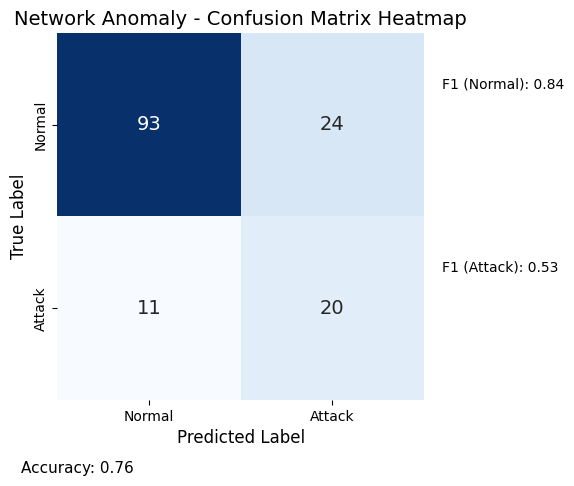

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Define true and predicted labels
y_true_n = df_visual_network['GroundTruth_Label']
y_pred_n = df_visual_network['Predicted_Label']
labels = ['Normal', 'Attack']

# Confusion matrix
cm = confusion_matrix(y_true_n, y_pred_n)

# Extract F1-score from classification report
report_dict = classification_report(y_true_n, y_pred_n, target_names=labels, output_dict=True)
f1_attack = report_dict['Attack']['f1-score']
f1_normal = report_dict['Normal']['f1-score']
accuracy = report_dict['accuracy']

# Heatmap
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=labels, yticklabels=labels, cbar=False, square=True,
                 annot_kws={"size": 14})

# Labels and Title
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Network Anomaly - Confusion Matrix Heatmap', fontsize=14)

# F1-score and accuracy as text
plt.text(2.1, 0.3, f"F1 (Normal): {f1_normal:.2f}", fontsize=10)
plt.text(2.1, 1.3, f"F1 (Attack): {f1_attack:.2f}", fontsize=10)
plt.text(-0.2, 2.4, f"Accuracy: {accuracy:.2f}", fontsize=11)

plt.tight_layout()
plt.show()

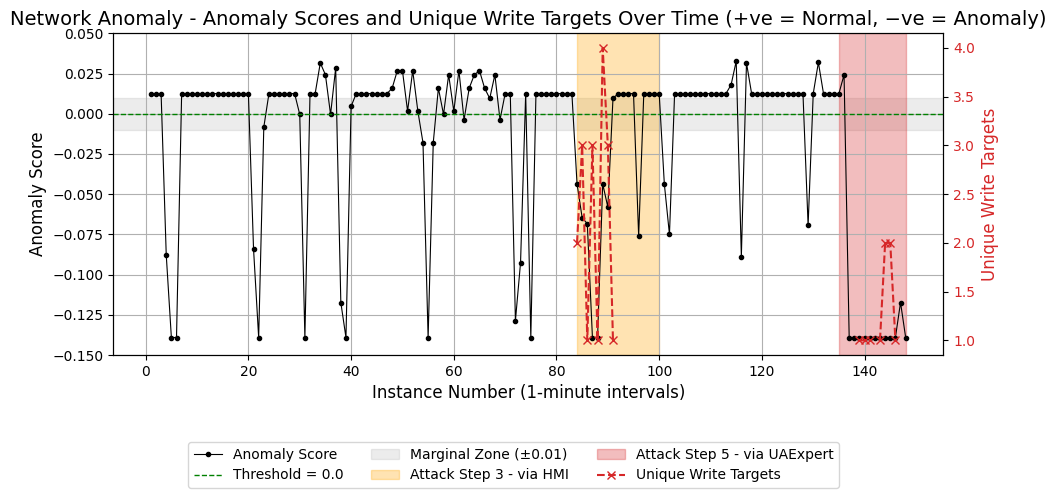

In [13]:
import matplotlib.pyplot as plt

# Define consistent red tone and other shared styles
ATTACK_COLOR = 'tab:red'
MARGINAL_ZONE_COLOR = 'gray'
THRESHOLD_LINE_COLOR = 'green'
HMI_COLOR = 'orange'

# Create dual-axis figure
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot anomaly score on primary y-axis
ax1.plot(
    df_visual_network['instance'],
    df_visual_network['Network_Anomaly_Score'],
    marker='o', linestyle='-', color='black', linewidth=0.8, markersize=3,
    label='Anomaly Score'
)

# Add threshold line and marginal zone
ax1.axhline(y=0.0, color=THRESHOLD_LINE_COLOR, linestyle='--', linewidth=1, label='Threshold = 0.0')
ax1.axhspan(-0.01, 0.01, color=MARGINAL_ZONE_COLOR, alpha=0.15, label='Marginal Zone (±0.01)')

# Mark attack periods
ax1.axvspan(attack_via_HMI[0], attack_via_HMI[1], color=HMI_COLOR, alpha=0.3, label='Attack Step 3 - via HMI')
ax1.axvspan(attack_via_UAExpert[0], attack_via_UAExpert[1], color=ATTACK_COLOR, alpha=0.3, label='Attack Step 5 - via UAExpert')

# Set labels and limits for anomaly score
ax1.set_xlabel("Instance Number (1-minute intervals)", fontsize=12)
ax1.set_ylabel("Anomaly Score", fontsize=12)
ax1.set_ylim(-0.15, 0.05)
ax1.grid(True)

# Create secondary y-axis for write targets
ax2 = ax1.twinx()
ax2.plot(
    df_visual_network['instance'],
    df_visual_network['unique_write_targets_count'],
    color=ATTACK_COLOR, linestyle='--', marker='x',
    label='Unique Write Targets'
)
ax2.set_ylabel("Unique Write Targets", fontsize=12, color=ATTACK_COLOR)
ax2.tick_params(axis='y', labelcolor=ATTACK_COLOR)

# Set title
plt.title("Network Anomaly - Anomaly Scores and Unique Write Targets Over Time (+ve = Normal, −ve = Anomaly)", fontsize=14)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

# Tidy up layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Display the figure
plt.savefig("network_anomaly_over_time.png", dpi=600, bbox_inches='tight')
plt.show()

Different format for publication

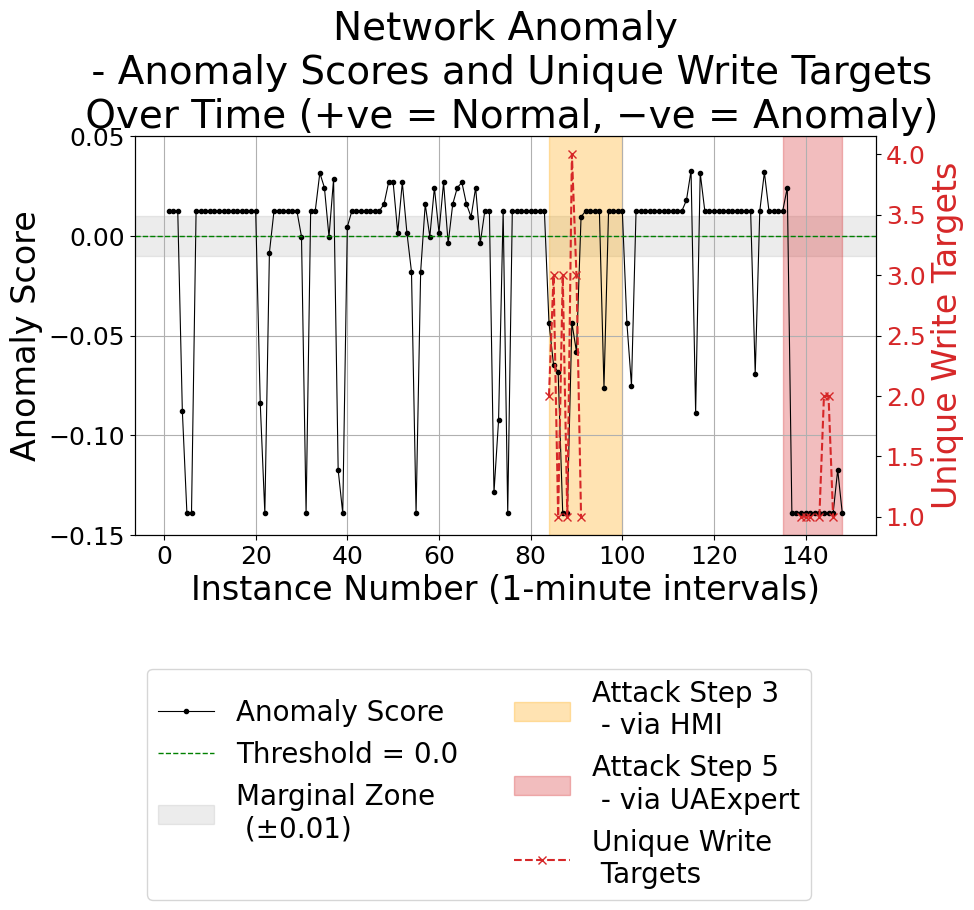

In [14]:
import matplotlib.pyplot as plt

# Define consistent red tone and other shared styles
ATTACK_COLOR = 'tab:red'
MARGINAL_ZONE_COLOR = 'gray'
THRESHOLD_LINE_COLOR = 'green'
HMI_COLOR = 'orange'

# Create dual-axis figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot anomaly score on primary y-axis
ax1.plot(
    df_visual_network['instance'],
    df_visual_network['Network_Anomaly_Score'],
    marker='o', linestyle='-', color='black', linewidth=0.8, markersize=3,
    label='Anomaly Score'
)

# Add threshold line and marginal zone
ax1.axhline(y=0.0, color=THRESHOLD_LINE_COLOR, linestyle='--', linewidth=1, label='Threshold = 0.0')
ax1.axhspan(-0.01, 0.01, color=MARGINAL_ZONE_COLOR, alpha=0.15, label='Marginal Zone\n (±0.01)')

# Mark attack periods
ax1.axvspan(attack_via_HMI[0], attack_via_HMI[1], color=HMI_COLOR, alpha=0.3, label='Attack Step 3\n - via HMI')
ax1.axvspan(attack_via_UAExpert[0], attack_via_UAExpert[1], color=ATTACK_COLOR, alpha=0.3, label='Attack Step 5\n - via UAExpert')

# Set labels and limits for anomaly score
ax1.set_xlabel("Instance Number (1-minute intervals)", fontsize=24)
ax1.set_ylabel("Anomaly Score", fontsize=24)
ax1.set_ylim(-0.15, 0.05)
ax1.grid(True)
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# Create secondary y-axis for write targets
ax2 = ax1.twinx()
ax2.plot(
    df_visual_network['instance'],
    df_visual_network['unique_write_targets_count'],
    color=ATTACK_COLOR, linestyle='--', marker='x',
    label='Unique Write\n Targets'
)
ax2.set_ylabel("Unique Write Targets", fontsize=24, color=ATTACK_COLOR)
ax2.tick_params(axis='y', labelcolor=ATTACK_COLOR, labelsize=18)

# Set title
plt.title("Network Anomaly\n - Anomaly Scores and Unique Write Targets\n Over Time (+ve = Normal, −ve = Anomaly)", fontsize=28)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=20)

# Tidy up layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Display the figure
plt.savefig("network_anomaly_over_time_bigfontsize.png", dpi=600, bbox_inches='tight')
plt.show()

**Interpretations of network anomalies:**

*   Indicated in the orange zone (attack step 3), the model detecting the network anomaly is less competent in detecting the manipulation via HMI.
*   Indicated in the red zone (attack step 5), the model is more competent in detecting the manipulation via UAExpert.
*   Indicated in the non-coloured zone, where we do not expect any anomalies to be detected on the OPC UA network, it is noted that the model has some false positives periodically over time.
*   Indicated in the grey zone, where we define as the marginal zone (a range from -0.01 to 0.01) for decision results on network anomaly detection, there are 12 out of 148 instances (8%) fell into a marginal zone.

In [15]:
# Assign ground truth
df_network['GroundTruth_NetworkLabel'] = df_network['instance'].apply(
    lambda x: 1 if (84 <= x <= 100) or (135 <= x <= 148) else 0
)

# Assign predicted label based on anomaly score
df_network['Predicted_NetworkLabel'] = df_network['Network_Anomaly_Score'].apply(
    lambda x: 1 if x < 0 else 0
)

In [16]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,timestamp,node_ids_written,source_ports,message_sizes,explanation,anomaly_score,timestamp_bst,network_alarm_flag,Network_Label_3Class,GroundTruth_NetworkLabel,Predicted_NetworkLabel
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:35:00+01:00,0,Network - Normal,0,0
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:36:00+01:00,0,Network - Normal,0,0
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-09 14:37:00+01:00,0,Network - Normal,0,0
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,2025-05-09 13:38:00,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected,-0.087744,2025-05-09 14:38:00+01:00,0,Network - Anomaly,0,1
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,2025-05-09 13:39:00,-,"53373, 53218","253, 100, 204, 189, 255",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 14:39:00+01:00,0,Network - Anomaly,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,2025-05-09 15:58:00,"-, MCDData.GetBox_signal, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 159",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 16:58:00+01:00,1,Network - Anomaly,1,1
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,2025-05-09 15:59:00,"-, MCDData.RotatePosition, MCDData.Gripper_Z_S...","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 16:59:00+01:00,1,Network - Anomaly,1,1
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,2025-05-09 16:00:00,"-, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected,-0.139128,2025-05-09 17:00:00+01:00,1,Network - Anomaly,1,1
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,2025-05-09 16:01:00,-,"52131, 53373, 53218","85, 66, 253, 100, 204",Unusual OPC UA write pattern detected,-0.117374,2025-05-09 17:01:00+01:00,0,Network - Anomaly,1,1


In [17]:
df_network.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance                    148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

Note: GroundTruth_NetworkLabel is the ground truth covering the entire 148 1-minute time interval, regardless the attack steps. Therefore this column is not only used for classification report related to network anomaly detection model, but also the 1st and 2nd decision fusion for preparation of the classification report.

In [18]:
df_network.to_csv('network_anomaly_view.csv', index=False)

from google.colab import files
files.download('network_anomaly_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Process Anomalies

In [19]:
uploaded = files.upload()

# Load Process Data with Class Scores calculated by LSTM-FCN
df_process = pd.read_csv("NX_predictions_09May_instances_with_alarms.csv")


Saving NX_predictions_09May_instances_with_alarms.csv to NX_predictions_09May_instances_with_alarms.csv


In [20]:
# Formattng
df_process.columns = df_process.columns.str.strip()

# Rename columns and reassign
df_process = df_process.rename(columns={
    'Instance': 'instance',
    'Predicted_Label': 'Process_Predicted_Label'
})

df_process['instance'] = df_process['instance'].astype(int)

In [21]:
# Convert probability percentage strings to float values (e.g., "99.99%" → 0.9999)
prob_cols = ['Prob_Class_0', 'Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']
for col in prob_cols:
    if df_process[col].dtype == 'object':
        df_process[col] = df_process[col].str.rstrip('%').astype(float) / 100.0

We define the process score achieved the following values as high confidence:



*   Normal cases: probability value 0 - 0.2
*   Threat cases: probability value 0.8 - 1



In [22]:
# Find the maximum probability of the threat classes
df_process['process_score'] = df_process[['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']].max(axis=1)

# Apply 3-class label logic
def classify_process(score):
    if score <= 0.20:
        return 'Process - Normal'
    elif score >= 0.80:
        return 'Process - Anomaly'
    else:
        return 'Process - Marginal'

df_process['Process_Label_3Class'] = df_process['process_score'].apply(classify_process)

In [23]:
df_process['Process_Label_3Class'].value_counts()

,count
Process_Label_3Class,
Process - Normal,90
Process - Anomaly,8


In [24]:
# Filter marginal cases
p_marginal_cases = df_process[df_process['Process_Label_3Class'] == 'Process - Marginal']

# Get instance numbers (assuming 'instance' column exists)
p_marginal_instance_numbers = p_marginal_cases['instance'].tolist()

# Show result
print("Process Marginal Instances:", p_marginal_instance_numbers)

Process Marginal Instances: []


In [25]:
df_process['Minute'] = pd.to_datetime(df_process['Minute']).dt.tz_localize("Europe/London")

In [26]:
df_process

,instance,Minute,Process_Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Label_Description,alarm_count,high_priority_count,sources,float_mean,float_max,float_min,process_score,Process_Label_3Class
0,0,2025-05-09 14:39:00+01:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0000,Process - Normal
1,1,2025-05-09 14:40:00+01:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0000,Process - Normal
2,2,2025-05-09 14:41:00+01:00,0,0.9993,0.0000,0.0006,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0006,Process - Normal
3,3,2025-05-09 14:42:00+01:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0000,Process - Normal
4,4,2025-05-09 14:43:00+01:00,0,0.9998,0.0000,0.0001,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0001,Process - Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,93,2025-05-09 16:57:00+01:00,0,0.9482,0.0464,0.0012,0.0025,0.0018,Label 0: Normal_NoIntervention,2.0,0.0,prov:default:/tag:Conveyor3_Speed:/alm:High Sp...,20025.0,40000.0,50.0,0.0464,Process - Normal
94,94,2025-05-09 16:58:00+01:00,1,0.0001,0.9978,0.0001,0.0002,0.0019,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN,0.9978,Process - Anomaly
95,95,2025-05-09 16:59:00+01:00,1,0.0001,0.9942,0.0000,0.0001,0.0055,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN,0.9942,Process - Anomaly
96,96,2025-05-09 17:00:00+01:00,4,0.0000,0.0013,0.0001,0.0002,0.9984,Label 4: Gripper_RotationDeviation,0.0,0.0,NaN,NaN,NaN,NaN,0.9984,Process - Anomaly


**From the process-only detection results, there is no marginal cases detected. There no ambiguous cases that could not be confidently classified as either normal or anomalous.**

**However, data captured on process data is not complete with missing data during the data collection process from Siemens NX MCD. This justifies the integration of network-level data for decision fusion, as it provides complementary context to resolve uncertainty in missing instances.**

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define ground truth based on your process-specific attack windows
df_process['GroundTruth_ProcessLabel'] = df_process['instance'].apply(
    lambda x: 1 if (56 <= x <= 66) or (88 <= x <= 97) else 0
)

# Define prediction using thresholded score
df_process['Predicted_ProcessLabel'] = df_process['process_score'].apply(
    lambda x: 1 if x >= 0.80 else 0
)

In [28]:
y_true_p = df_process['GroundTruth_ProcessLabel']
y_pred_p = df_process['Predicted_ProcessLabel']

# Generate confusion matrix and classification report
cm = confusion_matrix(y_true_p, y_pred_p)
report = classification_report(y_true_p, y_pred_p, target_names=['Normal', 'Attack'])

print("Confusion Matrix:\n", cm)
print("\nClassification Report - Process Anomaly:\n", report)

Confusion Matrix:
 [[77  0]
 [13  8]]

Classification Report - Process Anomaly:
               precision    recall  f1-score   support

      Normal       0.86      1.00      0.92        77
      Attack       1.00      0.38      0.55        21

    accuracy                           0.87        98
   macro avg       0.93      0.69      0.74        98
weighted avg       0.89      0.87      0.84        98



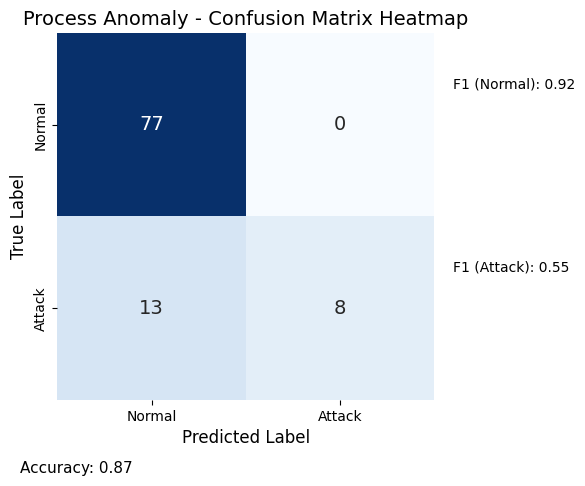

In [29]:
# Extract metrics for annotation
report_dict = classification_report(y_true_p, y_pred_p, target_names=['Normal', 'Attack'], output_dict=True)
f1_attack = report_dict['Attack']['f1-score']
f1_normal = report_dict['Normal']['f1-score']
accuracy = report_dict['accuracy']

# Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'],
            annot_kws={"size": 14})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Process Anomaly - Confusion Matrix Heatmap', fontsize=14)

# Add F1-score and accuracy annotations
plt.text(2.1, 0.3, f"F1 (Normal): {f1_normal:.2f}", fontsize=10)
plt.text(2.1, 1.3, f"F1 (Attack): {f1_attack:.2f}", fontsize=10)
plt.text(-0.2, 2.4, f"Accuracy: {accuracy:.2f}", fontsize=11)

plt.tight_layout()
plt.show()

The following graph shows anomaly scores for all the available data. The missing period is handled in the merging process showing in next section.   

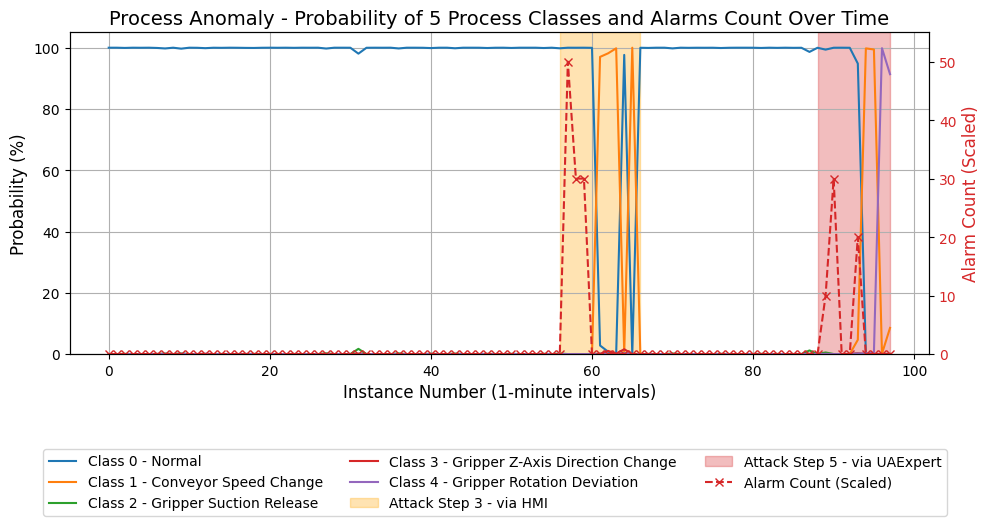

In [30]:
import matplotlib.pyplot as plt

# Shared color settings
ATTACK_COLOR = 'tab:red'
HMI_COLOR = 'orange'
MARGINAL_ZONE_COLOR = 'gray'
THRESHOLD_LINE_COLOR = 'green'

# Create figure and dual-axis
fig, ax1 = plt.subplots(figsize=(10, 4))

# Class label descriptions
label_desc = [
    'Class 0 - Normal',
    'Class 1 - Conveyor Speed Change',
    'Class 2 - Gripper Suction Release',
    'Class 3 - Gripper Z-Axis Direction Change',
    'Class 4 - Gripper Rotation Deviation'
]

# Plot class probabilities (multiclass time series)
for i in range(5):
    ax1.plot(df_process['instance'], df_process[f'Prob_Class_{i}'] * 100,
             label=label_desc[i], linewidth=1.5)

# Format primary Y-axis (probability)
ax1.set_ylabel("Probability (%)", fontsize=12)
ax1.set_ylim(0, 105)
ax1.grid(True)

# Secondary Y-axis for scaled alarm count
ax2 = ax1.twinx()
ax2.plot(
    df_process['instance'],
    df_process['alarm_count'] * 10,
    marker='x', linestyle='--', color=ATTACK_COLOR, linewidth=1.5,
    label='Alarm Count (Scaled)'
)
ax2.set_ylabel("Alarm Count (Scaled)", fontsize=12, color=ATTACK_COLOR)
ax2.tick_params(axis='y', labelcolor=ATTACK_COLOR)
ax2.set_ylim(0, 55)

# Attack periods
attack_hmi = (56, 66)
attack_ua = (88, 97)
ax1.axvspan(attack_hmi[0], attack_hmi[1], color=HMI_COLOR, alpha=0.3, label='Attack Step 3 - via HMI')
ax1.axvspan(attack_ua[0], attack_ua[1], color=ATTACK_COLOR, alpha=0.3, label='Attack Step 5 - via UAExpert')

# X-axis setup
ax1.set_xlabel("Instance Number (1-minute intervals)", fontsize=12)
plt.xticks(rotation=45)

# Title
plt.title("Process Anomaly - Probability of 5 Process Classes and Alarms Count Over Time", fontsize=14)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Show plot
plt.savefig("process_anomaly_over_time.png", dpi=600, bbox_inches='tight')
plt.show()

Different format for publication

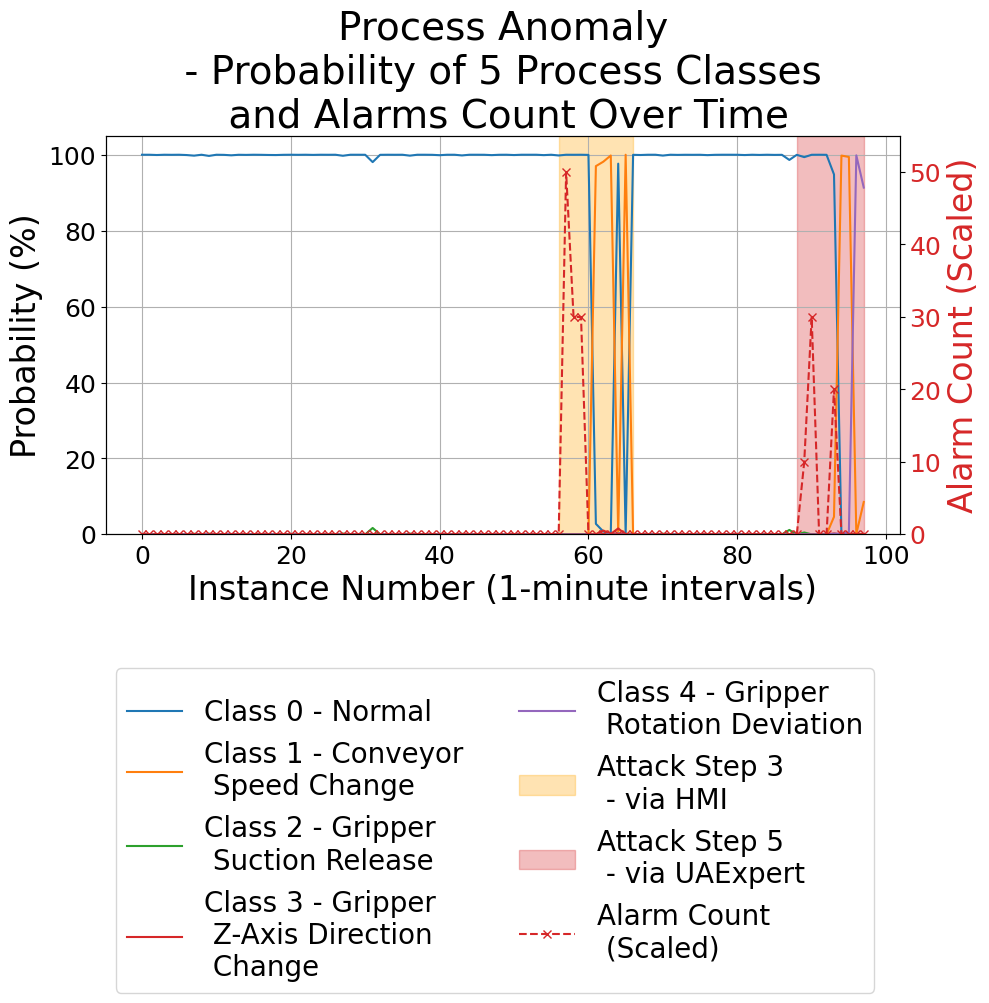

In [31]:
import matplotlib.pyplot as plt

# Shared color settings
ATTACK_COLOR = 'tab:red'
HMI_COLOR = 'orange'
MARGINAL_ZONE_COLOR = 'gray'
THRESHOLD_LINE_COLOR = 'green'

# Create figure and dual-axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Class label descriptions
label_desc = [
    'Class 0 - Normal',
    'Class 1 - Conveyor\n Speed Change',
    'Class 2 - Gripper\n Suction Release',
    'Class 3 - Gripper\n Z-Axis Direction\n Change',
    'Class 4 - Gripper\n Rotation Deviation'
]

# Plot class probabilities (multiclass time series)
for i in range(5):
    ax1.plot(df_process['instance'], df_process[f'Prob_Class_{i}'] * 100,
             label=label_desc[i], linewidth=1.5)

# Format primary Y-axis (probability)
ax1.set_ylabel("Probability (%)", fontsize=24)
ax1.set_ylim(0, 105)
ax1.grid(True)
ax1.tick_params(axis='y', labelsize=18)
ax1.tick_params(axis='x', labelsize=18)

# Secondary Y-axis for scaled alarm count
ax2 = ax1.twinx()
ax2.plot(
    df_process['instance'],
    df_process['alarm_count'] * 10,
    marker='x', linestyle='--', color=ATTACK_COLOR, linewidth=1.5,
    label='Alarm Count\n (Scaled)'
)
ax2.set_ylabel("Alarm Count (Scaled)", fontsize=24, color=ATTACK_COLOR)
ax2.tick_params(axis='y', labelcolor=ATTACK_COLOR, labelsize=18)
ax2.set_ylim(0, 55)

# Attack periods
attack_hmi = (56, 66)
attack_ua = (88, 97)
ax1.axvspan(attack_hmi[0], attack_hmi[1], color=HMI_COLOR, alpha=0.3, label='Attack Step 3\n - via HMI')
ax1.axvspan(attack_ua[0], attack_ua[1], color=ATTACK_COLOR, alpha=0.3, label='Attack Step 5\n - via UAExpert')

# X-axis setup
ax1.set_xlabel("Instance Number (1-minute intervals)", fontsize=24)
plt.xticks(rotation=45)

# Title
plt.title("Process Anomaly\n - Probability of 5 Process Classes \n and Alarms Count Over Time", fontsize=28)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=20)

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Show plot
plt.savefig("process_anomaly_over_time_bigfontsize.png", dpi=600, bbox_inches='tight')
plt.show()

**Interpretations of process anomalies:**

*   Indicated in the orange zone (attack step 3) and red zone (attack step 5), the model detecting the process anomaly is able to identify manipulations via HMI or UA Expert, and classify into different classes, such as conveyor speed manipulation (orange line).
*   Indicated in the non-coloured zone, where we do not expect any anomalies to be detected, it is noted that the model does not have any false positives.
*   Indicated in the red dotted line is the alarms detected by Ignition system, it is scaled to 10 times for visualisation.
*   There is no marginal cases for the supervised model for process data prediction, unlike the unsupervised model used for network data prediction which that 12 marginal / uncertain cases.





In [32]:
df_process.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype                        
---  ------                    --------------  -----                        
 0   instance                  98 non-null     int64                        
 1   Minute                    98 non-null     datetime64[ns, Europe/London]
 2   Process_Predicted_Label   98 non-null     int64                        
 3   Prob_Class_0              98 non-null     float64                      
 4   Prob_Class_1              98 non-null     float64                      
 5   Prob_Class_2              98 non-null     float64                      
 6   Prob_Class_3              98 non-null     float64                      
 7   Prob_Class_4              98 non-null     float64                      
 8   Label_Description         98 non-null     object                       
 9   alarm_count               98 non-null     flo

In [33]:
df_process.to_csv('process_anomaly_view.csv', index=False)

from google.colab import files
files.download('process_anomaly_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 2: Merge and normalize

### Merging Process Data and Network Data

In [34]:
df_fusion = df_network.merge(df_process, left_on='timestamp_bst', right_on='Minute', how='left')

In [35]:
df_fusion

,instance_x,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,timestamp,...,alarm_count,high_priority_count,sources,float_mean,float_max,float_min,process_score,Process_Label_3Class,GroundTruth_ProcessLabel,Predicted_ProcessLabel
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,2025-05-09 13:38:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,2025-05-09 13:39:00,...,0.0,0.0,NaN,NaN,NaN,NaN,0.0000,Process - Normal,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,2025-05-09 15:58:00,...,0.0,0.0,NaN,NaN,NaN,NaN,0.9978,Process - Anomaly,1.0,1.0
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,2025-05-09 15:59:00,...,0.0,0.0,NaN,NaN,NaN,NaN,0.9942,Process - Anomaly,1.0,1.0
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,2025-05-09 16:00:00,...,0.0,0.0,NaN,NaN,NaN,NaN,0.9984,Process - Anomaly,1.0,1.0
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,2025-05-09 16:01:00,...,0.0,0.0,NaN,NaN,NaN,NaN,0.9135,Process - Anomaly,1.0,1.0


In [36]:
df_fusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

Note
*   The process data are merged to the network data based on the timestamp with the datatype of **datetime64[ns, Europe/London]**.
*   The column timestamp_bst (column 15 shown above) contain all the 148 instance from 2025-05-09 14:35:00+01:00 to 2025-05-09 17:02:00+01:00.
*   When there are columns with the same name, such as instance (network) will automatically renamed to instance_x and instance (process) will automatically renamed to instance_y.






In [37]:
df_fusion.to_csv('fusion_network_process_view_before_confidence_logic.csv', index=False)

from google.colab import files
files.download('fusion_network_process_view_before_confidence_logic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The diagram below shows the pre-fusion result.

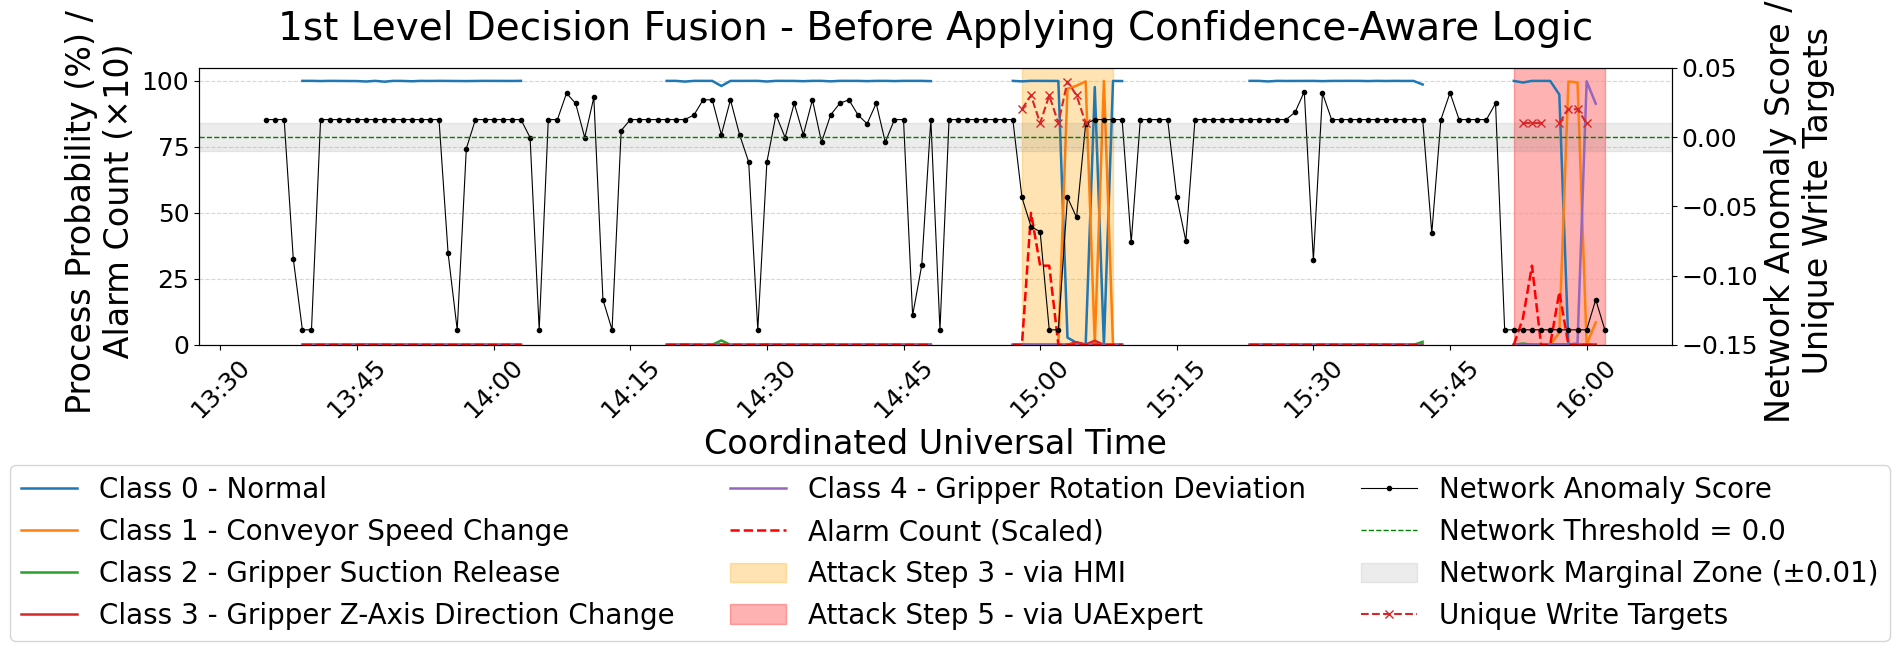

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator

# Ensure datetime format
df_fusion['timestamp_bst'] = pd.to_datetime(df_fusion['timestamp_bst'])

# Class labels
label_desc = {
    0: 'Class 0 - Normal',
    1: 'Class 1 - Conveyor Speed Change',
    2: 'Class 2 - Gripper Suction Release',
    3: 'Class 3 - Gripper Z-Axis Direction Change',
    4: 'Class 4 - Gripper Rotation Deviation'
}

# Create plot
fig, ax1 = plt.subplots(figsize=(18, 5))

# Plot process prediction probabilities
for i in range(5):
    ax1.plot(df_fusion['timestamp_bst'], df_fusion[f'Prob_Class_{i}'] * 100,
             label=label_desc[i], linewidth=1.8)

# Plot scaled alarm count
ax1.plot(df_fusion['timestamp_bst'], df_fusion['alarm_count'] * 10,
         linestyle='--', color='red', linewidth=1.8, label='Alarm Count (Scaled)')

# Highlight attack zones
ax1.axvspan(attackviaHMI_start, attackviaHMI_end, color='orange', alpha=0.3, label='Attack Step 3 - via HMI')
ax1.axvspan(attackviaUA_start, attackviaUA_end, color='red', alpha=0.3, label='Attack Step 5 - via UAExpert')

# Y-axis (primary) - process scale
ax1.set_ylabel("Process Probability (%) / \n Alarm Count (×10)", fontsize=24)
ax1.set_ylim(0, 105)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.grid(False, axis='x')

# X-axis: Time formatting
ax1.set_xlabel("Coordinated Universal Time", fontsize=24)
ax1.xaxis.set_major_locator(MinuteLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis='x', rotation=45, labelsize=18)
ax1.tick_params(axis='y', labelsize=18)

# Secondary Y-axis: Network anomaly score + write targets
ax2 = ax1.twinx()
ax2.plot(df_fusion['timestamp_bst'], df_fusion['Network_Anomaly_Score'],
         color='black', marker='o', markersize=3, linewidth=0.8, label='Network Anomaly Score')
ax2.axhline(y=0.0, color='green', linestyle='--', linewidth=1, label='Network Threshold = 0.0')
ax2.axhspan(-0.01, 0.01, color='gray', alpha=0.15, label='Network Marginal Zone (±0.01)')
ax2.tick_params(axis='y', labelsize=18)

# Scaled write targets
scaled_targets = df_fusion['unique_write_targets_count'] * 0.01
ax2.plot(df_fusion['timestamp_bst'], scaled_targets,
         color='tab:red', linestyle='--', marker='x', markersize=6,
         label='Unique Write Targets')

# Secondary Y-axis config
ax2.set_ylabel("Network Anomaly Score / \n Unique Write Targets", fontsize=24)
ax2.set_ylim(-0.15, 0.05)

# Title
plt.title("1st Level Decision Fusion - Before Applying Confidence-Aware Logic",
          fontsize=28, pad=20)

# Unified legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2,
           loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=3, fontsize=20)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("1stFusion_View_Before_Confidence_Aware_Logc_bigger.png", dpi=600, bbox_inches='tight')
plt.show()



**Interpretations of graph combining the network anomalies and process anomalies with the same timeframe:**

*   Indicated by several coloured lines in blue, orange, green, red, purple lines are the process anomalies, several period of process data is missing during data collection, thus there is no corresponding scores displayed in these period.
*   Indicated in the orange zone (attack step 3) and red zone (attack step 5), the network and process models is able to identify manipulations via HMI or UA Expert. In particular, the model detecting process anomaly provided a classification of the manipulation, such as conveyor speed manipulation (orange line).
*   Indicated in the non-coloured zone, where we do not expect any anomalies, it is noted that the process anomaly detection model does not have any false positives, but there are false positives for the network anomaly detection model.
*   Indicated in the red dotted line is the alarms detected by Ignition system, it is scaled to 10 times for visualisation.
*   There is no marginal cases for the supervised model for process data prediction, unlike the unsupervised model used for network data prediction which that 12 marginal / uncertain cases (in grey zone with a range of -0.01 to 0.01).










## Step 3: Handling of Missing and Contradiction Decisons from Different Model (Confidence-Aware Logic)

**Why decision fusion?**

In this study, decision fusion is used to reconcile outputs from two complementary sources: OPC UA network anomaly detection (unsupervised) and process anomaly classification (supervised). The fusion is particularly important for:

1.   Bridging missing data gaps
2.   Handling marginal predictions where one model lacks confidence

To achieve more robust detection, when data is availiable for both models, confidence-aware rules are applied to resolve contradictions.

If process data is missing, network data becomes the primary signal for decision-making. Conversely, when network data is unavailable (though rare), decisions default to process-level indicators.

This design ensures **maximum coverage and interpretability**, even under incomplete data conditions.

**1. Bridging missing data gaps**



The following code is for understanding the situation of missing data in process anomaly file.

In [39]:
# Instances where process anomaly results are missing
missing_process = df_fusion[df_fusion['Process_Predicted_Label'].isna()][['instance_y', 'timestamp_bst']]
print("Instances with missing process data:")
print("Total missing process instances:", missing_process.shape[0])

total_instances = len(df_fusion)
missing_count = len(missing_process)
missing_percentage = (missing_count / total_instances) * 100
print(f"Total missing process instances: {missing_count} out of {total_instances} ({missing_percentage:.2f}%)")

print(missing_process.to_string(index=False))
missing_process.to_csv("missing_process_instances.csv", index=False)

Instances with missing process data:
Total missing process instances: 50
Total missing process instances: 50 out of 148 (33.78%)
 instance_y             timestamp_bst
        NaN 2025-05-09 14:35:00+01:00
        NaN 2025-05-09 14:36:00+01:00
        NaN 2025-05-09 14:37:00+01:00
        NaN 2025-05-09 14:38:00+01:00
        NaN 2025-05-09 15:04:00+01:00
        NaN 2025-05-09 15:05:00+01:00
        NaN 2025-05-09 15:06:00+01:00
        NaN 2025-05-09 15:07:00+01:00
        NaN 2025-05-09 15:08:00+01:00
        NaN 2025-05-09 15:09:00+01:00
        NaN 2025-05-09 15:10:00+01:00
        NaN 2025-05-09 15:11:00+01:00
        NaN 2025-05-09 15:12:00+01:00
        NaN 2025-05-09 15:13:00+01:00
        NaN 2025-05-09 15:14:00+01:00
        NaN 2025-05-09 15:15:00+01:00
        NaN 2025-05-09 15:16:00+01:00
        NaN 2025-05-09 15:17:00+01:00
        NaN 2025-05-09 15:18:00+01:00
        NaN 2025-05-09 15:49:00+01:00
        NaN 2025-05-09 15:50:00+01:00
        NaN 2025-05-09 15:51:00+01:

In [40]:
# Instances where network anomaly score is missing
missing_network = df_fusion[df_fusion['Network_Anomaly_Score'].isna()][['instance_x', 'timestamp_bst']]
print("Instances with missing network data:")
print(missing_network.to_string(index=False))

print("Total missing network instances:", missing_network.shape[0])
missing_network.to_csv("missing_network_instances.csv", index=False)

Instances with missing network data:
Empty DataFrame
Columns: [instance_x, timestamp_bst]
Index: []
Total missing network instances: 0


**2. Handling marginal predictions where one model lacks confidence**


If process data is missing, network data becomes the primary signal for decision-making. Conversely, when network data is unavailable (though rare), decisions default to process-level indicators.

However, from Step 1 above, the marginal cases include

*   Network Marginal Instances: [23, 30, 36, 40, 51, 53, 58, 60, 62, 67, 69, 91]
*   Process Marginal Instances: Nil

To handle the marginal instances, an adjustable knowledge-driven logic is developed to provide transparent decisions.

If the overall result align (i.e., network score and process score indicate normal), we use the classification of process score for explainability. If the overall result contradict (i.e., network score says normal, process classifer says threat, we compare the absolute value of the two score to see who has higher score.

If process confidence is low (process score is less than 0.8), and network score is anomalous (and wins by absolute confidence), then pick the most likely attack class from the process model — since network model does not distinguish attack types. This retains the fine-grained attack classification from process model.

In [41]:
def resolve_final_label_with_reason(row):
    import pandas as pd

    # Thresholds
    PROCESS_HIGH = 0.8
    PROCESS_LOW = 0.2

    # Extract inputs
    process_score = row.get('process_score', None)
    process_label = row.get('Process_Predicted_Label', None)
    network_score = row.get('Network_Anomaly_Score', None)
    alarm_count = row.get('alarm_count', 0)
    node_ids_written = str(row.get('node_ids_written', '')).strip()
    prob_class_0 = row.get('Prob_Class_0', 0)  # Confidence that it's normal

    # Marginal flags
    process_3class = row.get('Process_Label_3Class', 'Unknown')
    network_3class = row.get('Network_Label_3Class', 'Unknown')

    # Define availability
    process_missing = pd.isna(process_score) or pd.isna(process_label)
    network_missing = pd.isna(network_score)
    network_alarm = pd.notna(node_ids_written) and node_ids_written not in ['', '-', 'nan']

    # Derive network fallback label from highest anomaly class
    try:
        attack_scores = pd.to_numeric(row[['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']], errors='coerce')
        network_label = int(attack_scores.idxmax().split('_')[-1]) if not attack_scores.isna().all() else 0
    except:
        return pd.Series([0, 'Anomaly - Only Network Data Available (Fallback 0)', 1])

    # === CASE 1: Only network data available ===
    if process_missing:
        if network_missing:
            return pd.Series([None, 'Case 0: Insufficient Data', None])
        elif network_score < 0 or network_alarm:
            return pd.Series([network_label, 'Case 1 (Only Network Data Available): Likely Anomaly', 1])
        else:
            return pd.Series([0, 'Case 1 (Only Network Data Available): Likely Normal', 0])

    # === CASE 2: Only process data available ===
    if network_missing:
        if process_score >= PROCESS_HIGH or alarm_count > 0:
            return pd.Series([process_label, 'Case 2 (Only Precess Data Available): Likely Anomaly', 1])
        else:
            return pd.Series([0, 'Case 2 (Only Process Data Available): Likely Normal', 0])

    # === CASE 3: Both sources available ===
    if process_score >= PROCESS_HIGH or alarm_count > 0 or network_alarm:
        return pd.Series([process_label, 'Case 3 (Predictions Aligned): Anomaly - Process Score equals or greater than 0.8 or Alarm Triggered', 1])

    if process_score <= PROCESS_LOW and process_label == 0 and network_score >= 0:
        return pd.Series([0, 'Case 3 (Predictions Aligned): Normal - No Conflicting Result', 0])

    # === MARGINAL CASES / UNCERTAIN PREDICTIONS ===
    if network_3class == 'Network - Marginal':
        if process_label == 0: # when process models predict normal
            return pd.Series([0, 'Case 3 (Marginal Network Score): Normal - Network Marginal, Trusted Process', 0])
        else:   # when process models predict anomaly
            return pd.Series([process_label, 'Case 3 (Marginal Network Score): Anomaly - Network Marginal, Trusted Process', 1])

    if process_3class == 'Process - Marginal': # No actual cases
        if network_score < 0 or network_alarm:
            return pd.Series([network_label, 'Case 3 (Marginal Process Score): Anomaly - Process Marginal, Trusted Network', 1])
        else:
            return pd.Series([0, 'Case 3 (Marginal Process Score): Normal - Process Marginal, Trusted Network', 0])

    # === CONFLICT RESOLUTION ===
    # Case: Process says normal, network says anomaly (compare confidence of process normal class with absolute value of network anomaly score)
    if process_label == 0 and network_score < 0:
        if prob_class_0 > abs(network_score):
            return pd.Series([0, 'Case 3 (Predictions Conflicts): Normal - Process Predictions Override', 0])
        else:
            return pd.Series([network_label, 'Case 3 (Predictions Conflicts): Anomaly - Network Predictions Override)', 1])

    # Case: Process says threat, network says normal (disregards the network score during the resolution)
    if process_label != 0 and network_score >= 0:
        return pd.Series([process_label, 'Case 3 (Predictions Conflicts): Anomaly - Process Predictions Override', 1])

    # === FALLBACK ===
    return pd.Series([process_label, 'Unknown - No Clear Reason', 1 if process_label != 0 else 0])

In [42]:
df_fusion[['final_fused_label', 'decision_reason', 'final_binary_label']] = df_fusion.apply(resolve_final_label_with_reason, axis=1)

In [43]:
# Summary of the result after applying the fusion logic
df_fusion['decision_reason'].value_counts()

,count
decision_reason,
Case 3 (Predictions Aligned): Normal - No Conflicting Result,65
Case 1 (Only Network Data Available): Likely Normal,37
Case 3 (Predictions Aligned): Anomaly - Process Score equals or greater than 0.8 or Alarm Triggered,17
Case 1 (Only Network Data Available): Likely Anomaly,13
Case 3 (Predictions Conflicts): Normal - Process Predictions Override,12
"Case 3 (Marginal Network Score): Normal - Network Marginal, Trusted Process",4


In [44]:
# Count the number of records by the fused value
# Note: Please only refer to value 1 and value 4 for the process class as reference, not to be confused with the final_binary_label
df_fusion['final_fused_label'].value_counts()

,count
final_fused_label,
0.0,140
1.0,6
4.0,2


In [45]:
# Count the number of records by the fused binary value (the )
df_fusion['final_binary_label'].value_counts()

,count
final_binary_label,
0,118
1,30


The following diagrams are for visualising the fusion logic applied in the 1st level decision fusion.

The final_binary_label should be serves as the result for the 1st level decision fusion.

In [46]:
!pip install graphviz

Combined Case 1 (only network data available) and Case 2 (only process data available)

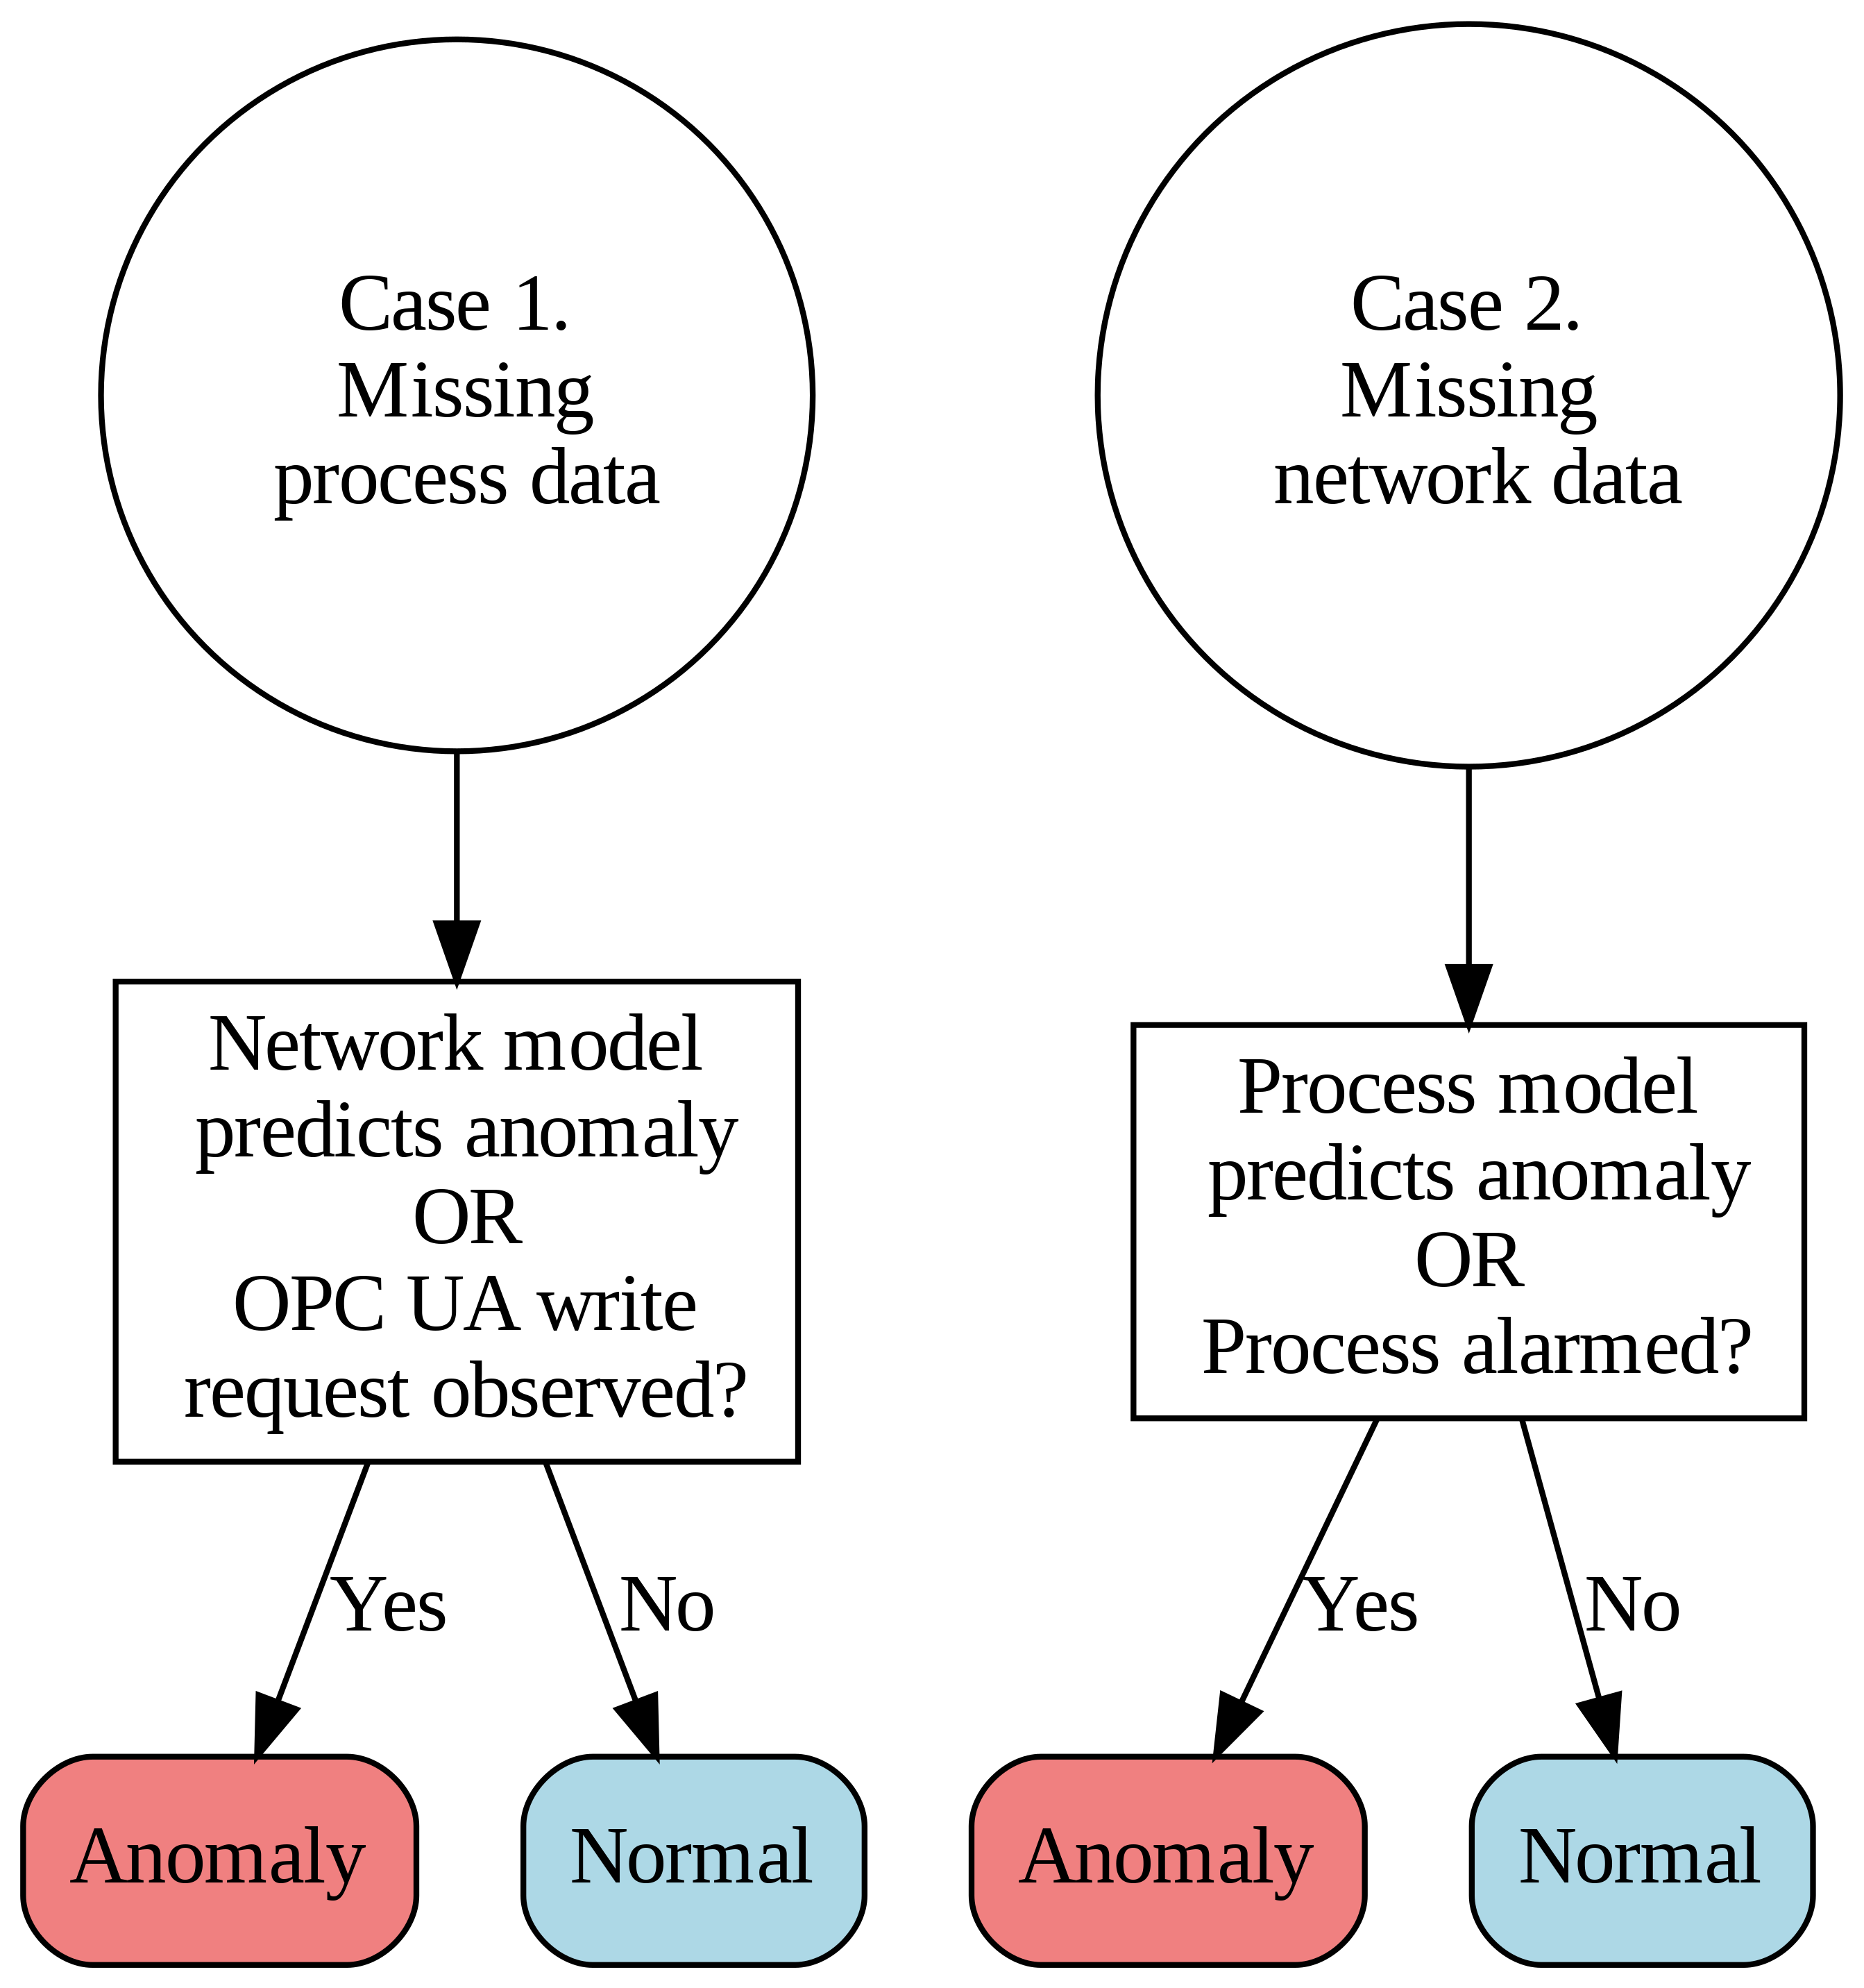

In [47]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Combined Logic: Case 1 and Case 2')

# Style definitions
decision_style = {'shape': 'rectangle'}
threat_style = {'style': 'filled', 'fillcolor': 'lightcoral', 'shape': 'box', 'style': 'rounded,filled'}
normal_style = {'style': 'filled', 'fillcolor': 'lightblue', 'shape': 'box', 'style': 'rounded,filled'}

# Case 1: Network Only
dot.node('C1', 'Case 1.\n Missing\n process data', shape='circle')
dot.node('Q1', 'Network model\n predicts anomaly\n OR\n OPC UA write\n request observed?', **decision_style)
dot.node('A1', 'Anomaly', **threat_style)
dot.node('N1', 'Normal', **normal_style)

# Case 2: Process Only
dot.node('C2', 'Case 2.\n Missing \n network data', shape='circle')
dot.node('Q2', 'Process model\n predicts anomaly\nOR\n Process alarmed?', **decision_style)
dot.node('A2', 'Anomaly', **threat_style)
dot.node('N2', 'Normal', **normal_style)

# Edges for Case 1
dot.edge('C1', 'Q1')
dot.edge('Q1', 'A1', label='Yes')
dot.edge('Q1', 'N1', label='No')

# Edges for Case 2
dot.edge('C2', 'Q2')
dot.edge('Q2', 'A2', label='Yes')
dot.edge('Q2', 'N2', label='No')

# Render and display
dot.attr(dpi='600')
dot.render('combined_case1_case2_logic', format='png', cleanup=True)

from IPython.display import Image, display
display(Image(filename='combined_case1_case2_logic.png'))

Case 3: Both network and process data are available, handling of marginal cases and conflicting results

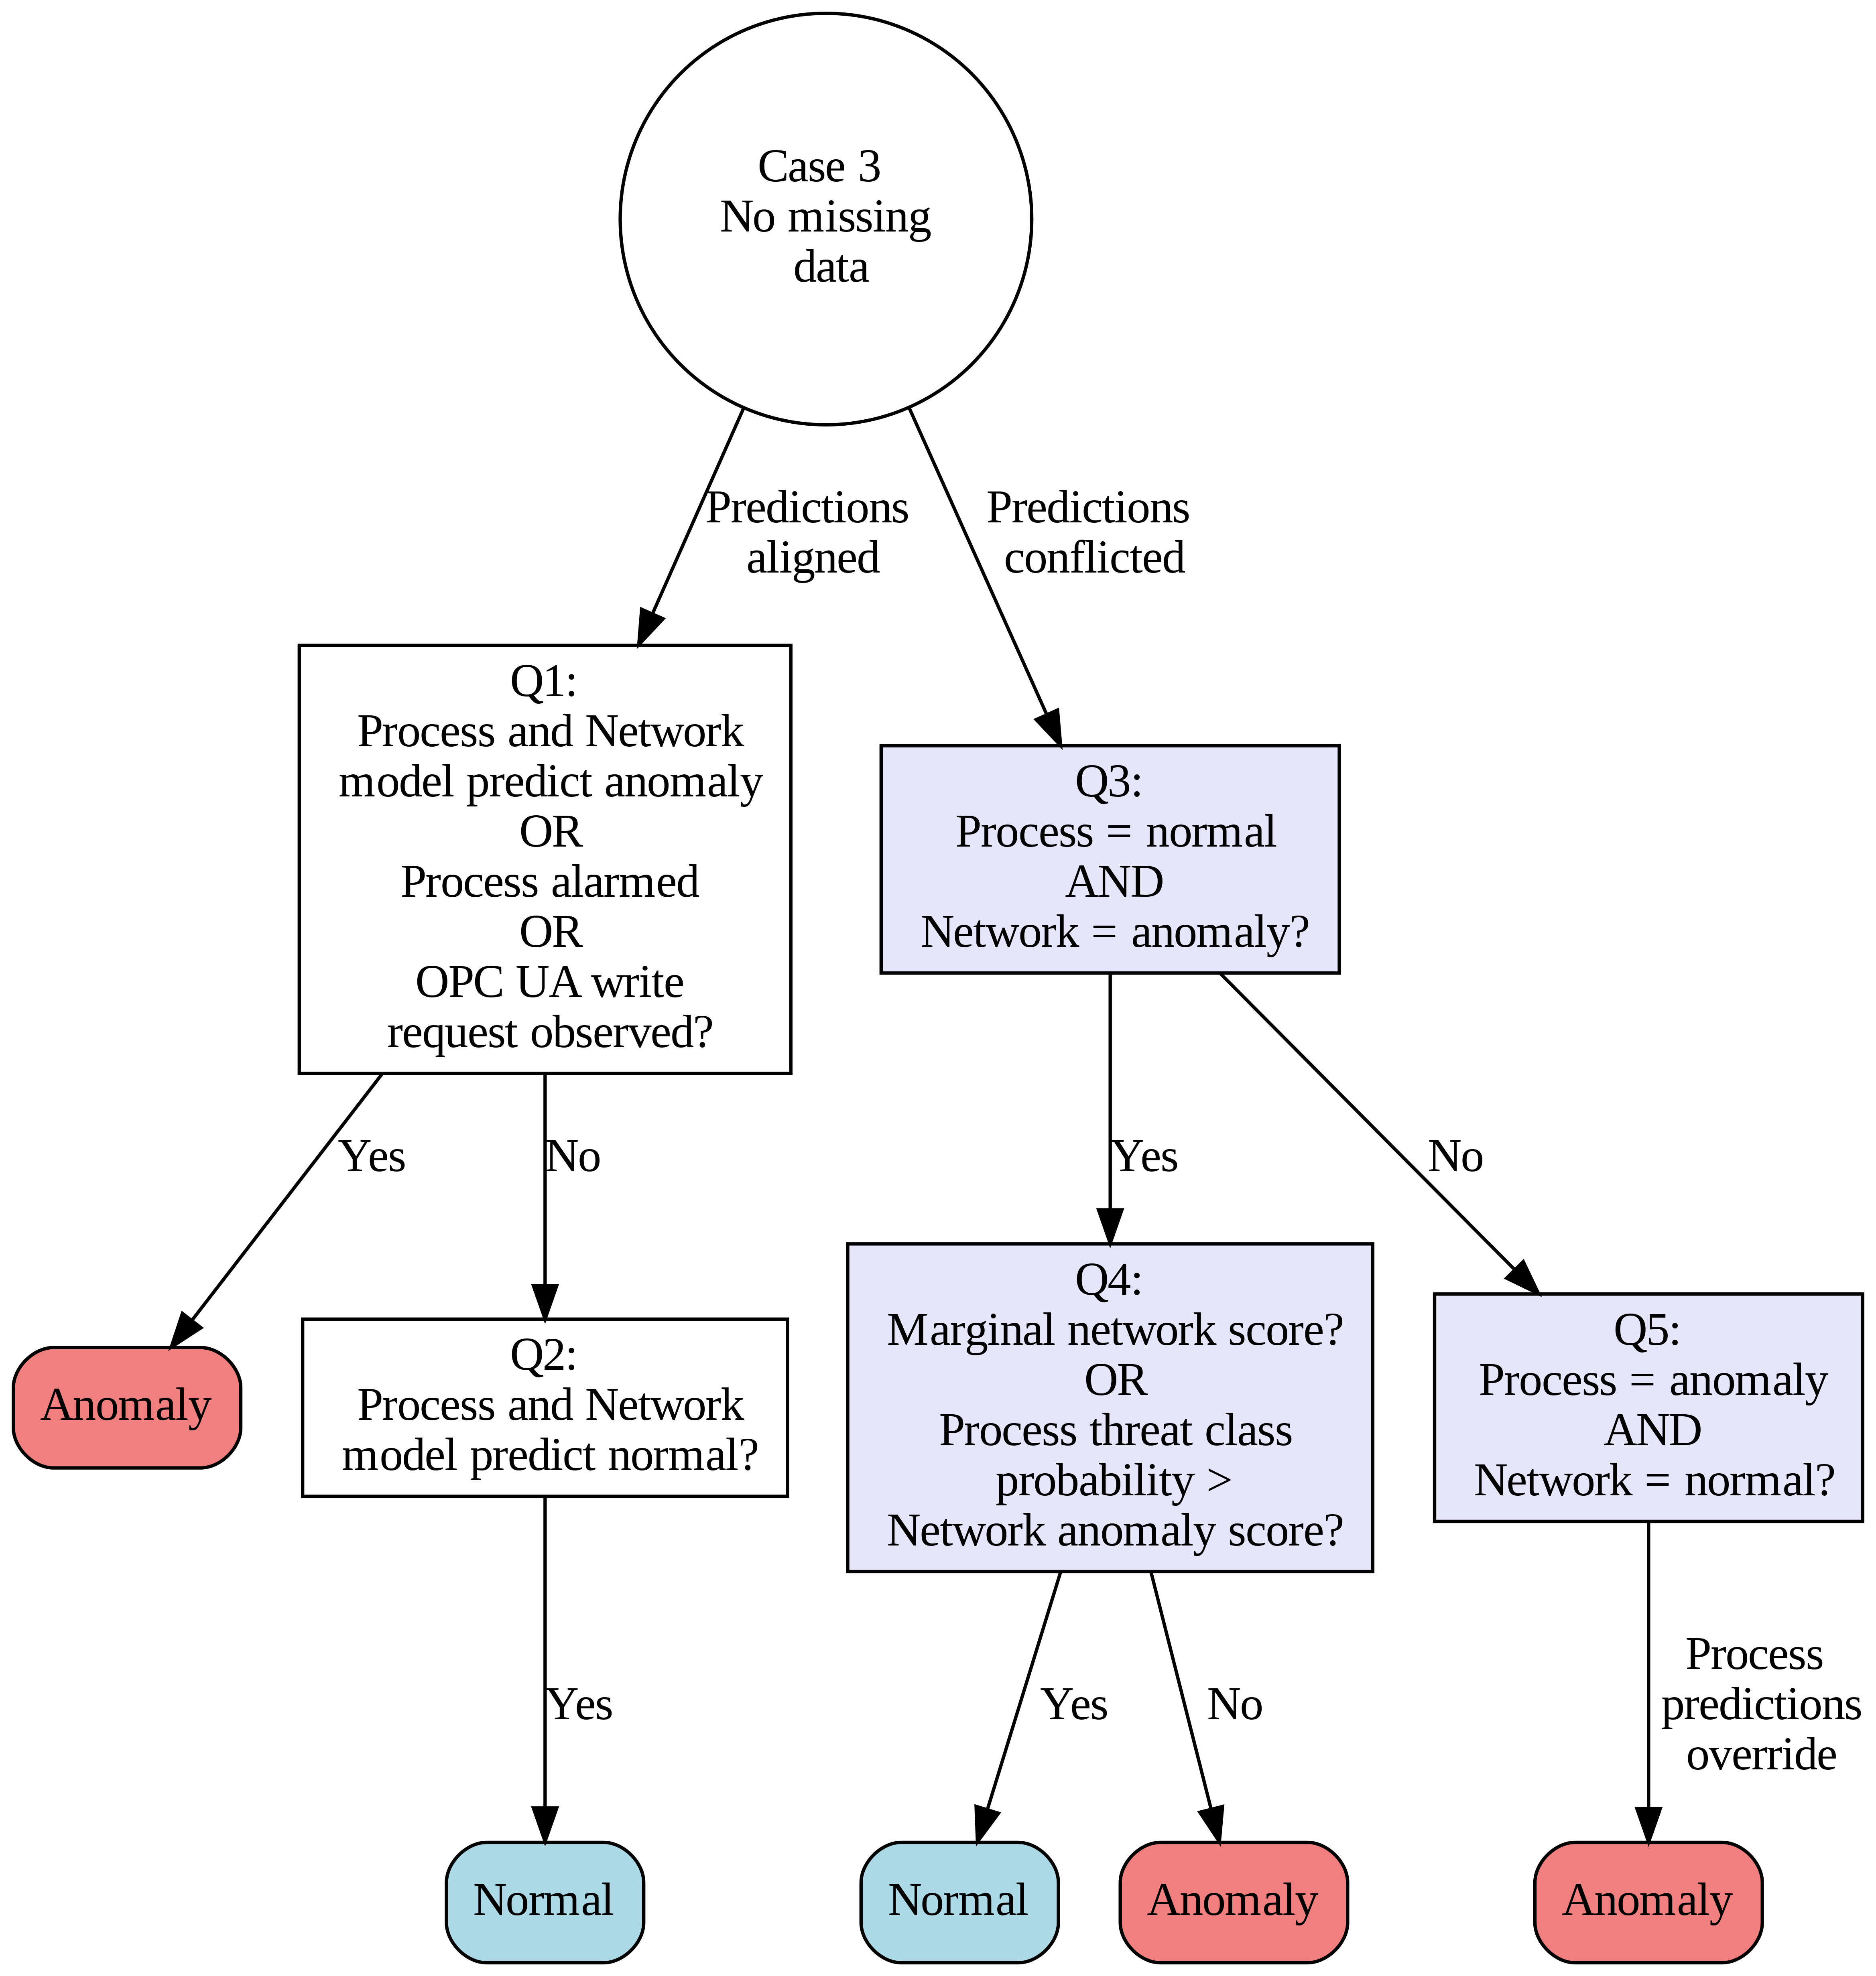

In [48]:
from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(comment='Case 3: Both Data Available + Conflict Resolution')

# Set global font size
dot.attr('node', fontsize='14')

# Style definitions
high_conf_style = {'shape': 'rectangle', 'style': 'filled', 'fillcolor': 'white'}
marginal_style = {'shape': 'rectangle', 'style': 'filled', 'fillcolor': 'lightyellow'}
conflict_style = {'shape': 'rectangle', 'style': 'filled', 'fillcolor': 'lavender'}
normal_style = {'style': 'filled', 'fillcolor': 'lightblue', 'shape': 'box', 'style': 'rounded,filled'}
threat_style = {'style': 'filled', 'fillcolor': 'lightcoral', 'shape': 'box', 'style': 'rounded,filled'}

# Start node
dot.node('A', 'Case 3 \n No missing \n data', shape='circle')

# High Confidence Decisions
dot.node('Q1', 'Q1:\n Process and Network\n model predict anomaly\n OR\n Process alarmed\n OR\n OPC UA write\n request observed?', **high_conf_style)
dot.node('A1', 'Anomaly', **threat_style)

dot.node('Q2', 'Q2:\n Process and Network\n model predict normal?', **high_conf_style)
dot.node('A2', 'Normal', **normal_style)

# Conflict Resolution Decisions
dot.node('Q3', 'Q3:\n Process = normal\n AND\n Network = anomaly?', **conflict_style)

dot.node('Q4', 'Q4:\n Marginal network score?\n OR\n Process threat class\n probability >\n Network anomaly score?', **conflict_style)
dot.node('A7', 'Normal', **normal_style)
dot.node('A8', 'Anomaly', **threat_style)

dot.node('Q5', 'Q5:\n Process = anomaly\n AND\n Network = normal?', **conflict_style)
dot.node('A9', 'Anomaly', **threat_style)

# Edges
dot.edge('A', 'Q1', label='Predictions\n aligned')
dot.edge('Q1', 'A1', label='Yes')
dot.edge('Q1', 'Q2', label='No')
dot.edge('Q2', 'A2', label='Yes')

dot.edge('A', 'Q3', label='Predictions\n conflicted')
dot.edge('Q3', 'Q4', label='Yes')
dot.edge('Q3', 'Q5', label='No')

dot.edge('Q4', 'A7', label='Yes')
dot.edge('Q4', 'A8', label='No')

dot.edge('Q5', 'A9', label='Process\n predictions\n override')

# Render and display
dot.attr(dpi='600')
dot.render('case3_flowchart', format='png', cleanup=True)
display(Image(filename='case3_flowchart.png'))

Merged three cases for publication

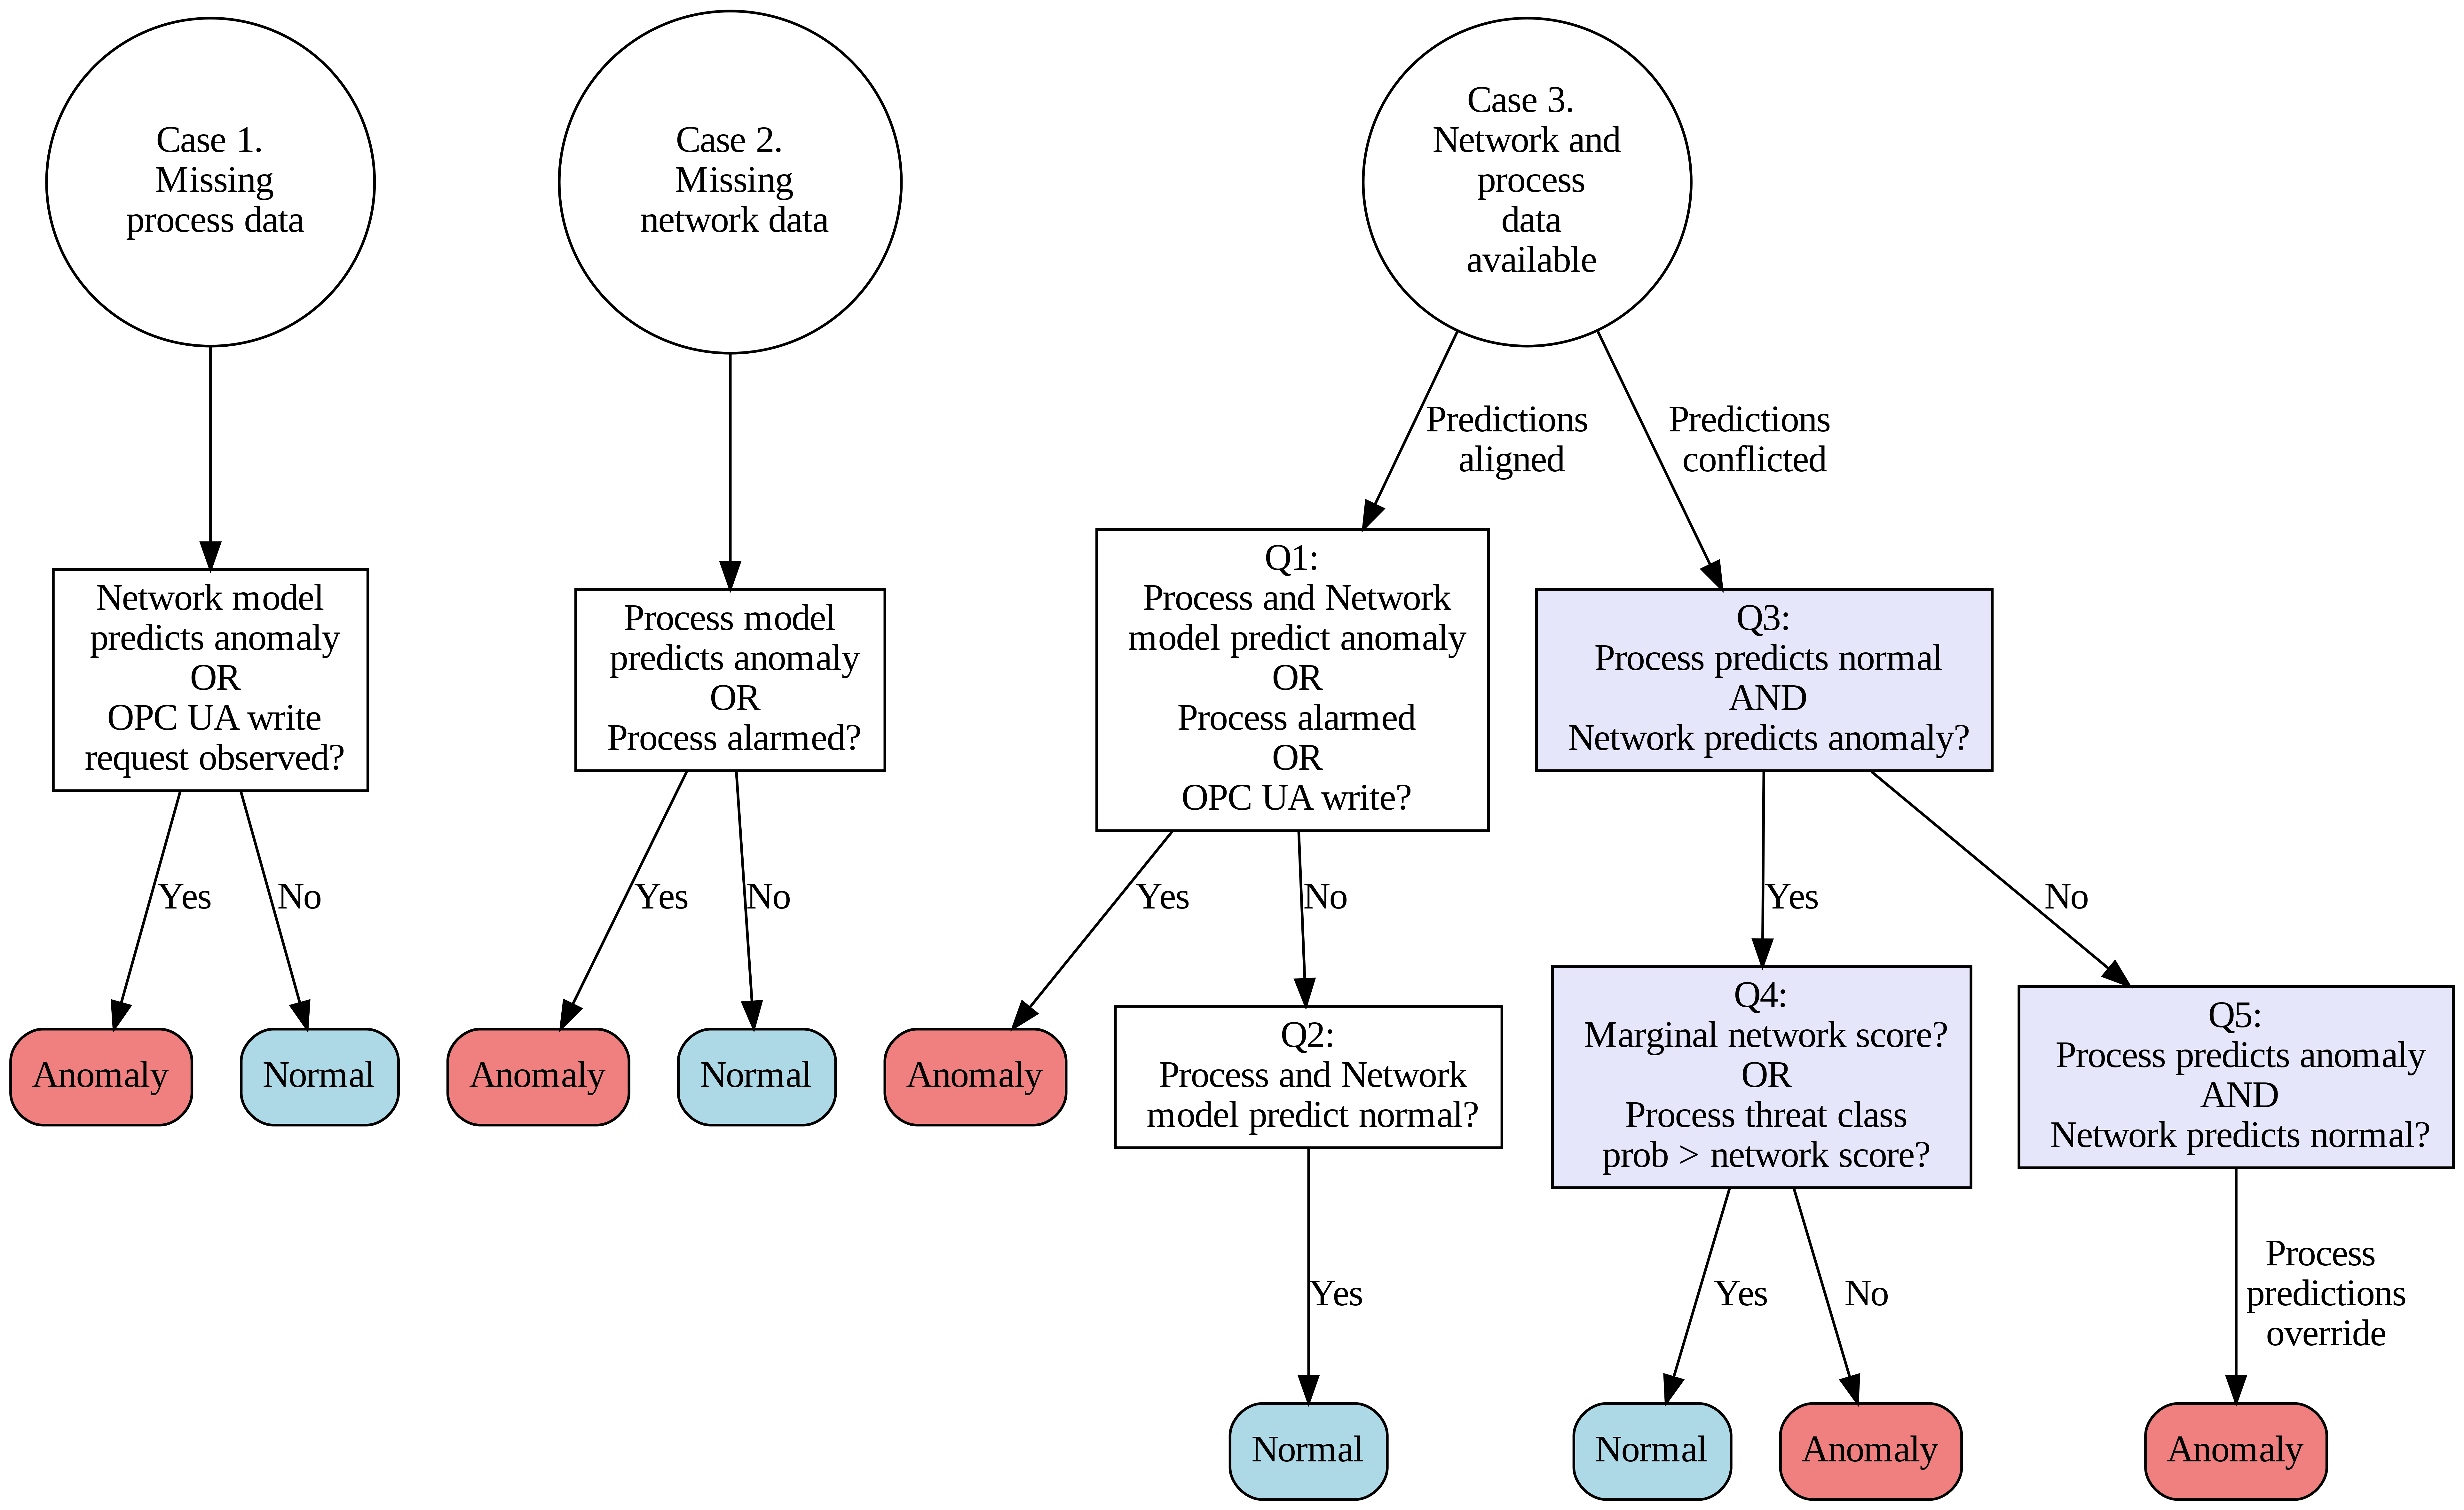

In [49]:
from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(comment='Combined Logic: Case 1, 2 and 3')
dot.attr(dpi='600')
dot.attr('node', fontsize='14')

# === Styles ===
decision_style = {'shape': 'rectangle'}
threat_style = {'style': 'rounded,filled', 'fillcolor': 'lightcoral', 'shape': 'box'}
normal_style = {'style': 'rounded,filled', 'fillcolor': 'lightblue', 'shape': 'box'}
marginal_style = {'shape': 'rectangle', 'style': 'filled', 'fillcolor': 'lightyellow'}
conflict_style = {'shape': 'rectangle', 'style': 'filled', 'fillcolor': 'lavender'}

# === Case 1: Network Only ===
dot.node('C1', 'Case 1.\n Missing\n process data', shape='circle')
dot.node('Q1', 'Network model\n predicts anomaly\n OR\n OPC UA write\n request observed?', **decision_style)
dot.node('A1', 'Anomaly', **threat_style)
dot.node('N1', 'Normal', **normal_style)
dot.edge('C1', 'Q1')
dot.edge('Q1', 'A1', label='Yes')
dot.edge('Q1', 'N1', label='No')

# === Case 2: Process Only ===
dot.node('C2', 'Case 2.\n Missing\n network data', shape='circle')
dot.node('Q2', 'Process model\n predicts anomaly\n OR\n Process alarmed?', **decision_style)
dot.node('A2', 'Anomaly', **threat_style)
dot.node('N2', 'Normal', **normal_style)
dot.edge('C2', 'Q2')
dot.edge('Q2', 'A2', label='Yes')
dot.edge('Q2', 'N2', label='No')

# === Case 3: Both Available + Conflict Resolution ===
dot.node('C3', 'Case 3. \nNetwork and\n process\n data\n available', shape='circle')
dot.node('Q3_1', 'Q1:\n Process and Network\n model predict anomaly\n OR\n Process alarmed\n OR\n OPC UA write?', **decision_style)
dot.node('A3_1', 'Anomaly', **threat_style)

dot.node('Q3_2', 'Q2:\n Process and Network\n model predict normal?', **decision_style)
dot.node('A3_2', 'Normal', **normal_style)

dot.edge('C3', 'Q3_1', label='Predictions\n aligned')
dot.edge('Q3_1', 'A3_1', label='Yes')
dot.edge('Q3_1', 'Q3_2', label='No')
dot.edge('Q3_2', 'A3_2', label='Yes')

# === Conflict: Process=Normal, Network=Anomaly ===
dot.node('Q3_3', 'Q3:\n Process predicts normal\n AND\n Network predicts anomaly?', **conflict_style)
dot.node('Q3_4', 'Q4:\n Marginal network score?\n OR\n Process threat class\n prob > network score?', **conflict_style)
dot.node('A3_3', 'Normal', **normal_style)
dot.node('A3_4', 'Anomaly', **threat_style)

# === Conflict: Process=Anomaly, Network=Normal ===
dot.node('Q3_5', 'Q5:\n Process predicts anomaly\n AND\n Network predicts normal?', **conflict_style)
dot.node('A3_5', 'Anomaly', **threat_style)

# Continue edges for conflict cases
dot.edge('C3', 'Q3_3', label='Predictions\n conflicted')
dot.edge('Q3_3', 'Q3_4', label='Yes')
dot.edge('Q3_3', 'Q3_5', label='No')

dot.edge('Q3_4', 'A3_3', label='Yes')
dot.edge('Q3_4', 'A3_4', label='No')
dot.edge('Q3_5', 'A3_5', label='Process\n predictions\n override')

# === Save and display ===
dot.render('combined_case123_logic', format='png', cleanup=True)
display(Image(filename='combined_case123_logic.png'))

In [50]:
df_fusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

The GroundTruth_NetworkLabel provides the ground truth for the entire timestamp from 2025-05-09 14:35:00+01:00 to 2025-05-09 17:02:00+01:00.

In [51]:
# Display final result, decision reason and ground truth for each timestamp
df_fusion[['timestamp_bst', 'final_binary_label', 'decision_reason', 'GroundTruth_NetworkLabel']]

,timestamp_bst,final_binary_label,decision_reason,GroundTruth_NetworkLabel
0,2025-05-09 14:35:00+01:00,0,Case 1 (Only Network Data Available): Likely N...,0
1,2025-05-09 14:36:00+01:00,0,Case 1 (Only Network Data Available): Likely N...,0
2,2025-05-09 14:37:00+01:00,0,Case 1 (Only Network Data Available): Likely N...,0
3,2025-05-09 14:38:00+01:00,1,Case 1 (Only Network Data Available): Likely A...,0
4,2025-05-09 14:39:00+01:00,0,Case 3 (Predictions Conflicts): Normal - Proce...,0
...,...,...,...,...
143,2025-05-09 16:58:00+01:00,1,Case 3 (Predictions Aligned): Anomaly - Proces...,1
144,2025-05-09 16:59:00+01:00,1,Case 3 (Predictions Aligned): Anomaly - Proces...,1
145,2025-05-09 17:00:00+01:00,1,Case 3 (Predictions Aligned): Anomaly - Proces...,1
146,2025-05-09 17:01:00+01:00,1,Case 3 (Predictions Aligned): Anomaly - Proces...,1


In [52]:
df_fusion.to_csv('fusion_network_process_view_with_confidence_logic.csv', index=False)

from google.colab import files
files.download('fusion_network_process_view_with_confidence_logic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 4: Compare Results

**Re-cap the classification report for nework anomaly data and the process anomaly**

In [53]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix and report - network anoamly
y_true_n = df_fusion['GroundTruth_NetworkLabel']
y_pred_n = df_fusion['Network_Predicted_Label']

conf_matrix = confusion_matrix(y_true_n, y_pred_n)
report = classification_report(y_true_n, y_pred_n, target_names=['Normal', 'Attack'])

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report - Network Anomaly:\n", report)

Confusion Matrix:
 [[93 24]
 [11 20]]

Classification Report - Network Anomaly:
               precision    recall  f1-score   support

      Normal       0.89      0.79      0.84       117
      Attack       0.45      0.65      0.53        31

    accuracy                           0.76       148
   macro avg       0.67      0.72      0.69       148
weighted avg       0.80      0.76      0.78       148



Prediction interpretation - Network anomaly

*   True Normal (TN) - normal correctly predicted as normal: 93
*   False Positive (FP) - normal incorrectly predicted as attack (false alarms): 24
*   False Negative (FN) - attack incorrectly predicted as normal (missed detection): 11
*   True Attack (TP): attack correctly predicted as attack: 20
*   Precision (Attack) = TP / (TP + FP) = 20 / (20 + 24) ≈ 0.45 (Many normal instances are wrongly classified as attacks)
*   Recall (Attack) = TP / (TP + FN) = 20 / (20 + 11) ≈ 0.65 (It detects 65% of real attacks but misses 35%)

In [54]:
# Assign variables for true and predicted labels - process anoamly
y_true_p = df_process['GroundTruth_ProcessLabel']
y_pred_p = df_process['Predicted_ProcessLabel']

# Generate confusion matrix and classification report - process anoamly
cm = confusion_matrix(y_true_p, y_pred_p)
report = classification_report(y_true_p, y_pred_p, target_names=['Normal', 'Attack'])

print("Confusion Matrix:\n", cm)
print("\nClassification Report - Process Anomaly:\n", report)

Confusion Matrix:
 [[77  0]
 [13  8]]

Classification Report - Process Anomaly:
               precision    recall  f1-score   support

      Normal       0.86      1.00      0.92        77
      Attack       1.00      0.38      0.55        21

    accuracy                           0.87        98
   macro avg       0.93      0.69      0.74        98
weighted avg       0.89      0.87      0.84        98



Prediction interpretation - Process anomaly

*   True Normal (TN) - normal correctly predicted as normal: 77
*   False Positive (FP) - normal incorrectly predicted as attack (false alarms): 0
*   False Negative (FN) - attack incorrectly predicted as normal (missed detection): 13
*   True Attack (TP): attack correctly predicted as attack: 8
*   Precision (Attack) = 8 / (8 + 0) = 1.00 (when it flags an attack, it is trule an attack)
*   Recall (Attack) = 8 / (8 + 13) ≈ 0.38 (it misses 62% of attacks)

This model is very conservative. It only predicts “attack” when it's very sure, but misses most attacks.

In [55]:
# Assign variables for true and predicted labels - fused anomaly
y_true_f = df_fusion['GroundTruth_NetworkLabel']
y_pred_f = df_fusion['final_binary_label']

# Step 2: Compute confusion matrix and classification report - fused anomaly
conf_matrix = confusion_matrix(y_true_f, y_pred_f)
report = classification_report(y_true_f, y_pred_f, target_names=['Normal', 'Attack'])

# Step 3: Display results
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report - 1st-Level OT Fusion:\n", report)

Confusion Matrix:
 [[107  10]
 [ 11  20]]

Classification Report - 1st-Level OT Fusion:
               precision    recall  f1-score   support

      Normal       0.91      0.91      0.91       117
      Attack       0.67      0.65      0.66        31

    accuracy                           0.86       148
   macro avg       0.79      0.78      0.78       148
weighted avg       0.86      0.86      0.86       148



Prediction interpretation - Fused anomaly

*   True Normal (TN) - normal correctly predicted as normal: 107
*   False Positive (FP) - normal incorrectly predicted as attack (false alarms): 10
*   False Negative (FN) - attack incorrectly predicted as normal (missed detection): 11
*   True Attack (TP): attack correctly predicted as attack: 20
*   Precision (Attack) =  20 / (20 + 10) ≈ 0.67
*   Recall (Attack) = 20 / (20 + 11) ≈ 0.65 (it misses 35% of attacks)

The fused model balances precision and recall better than the others.

### Overall performance of the 1st Level Decision Fusion

*   There is clear improvement after 1st-level OT fusion, particularly in balanced detection performance between the Normal and Attack classes.

1.   Improved balance across classes:

*   The network-only model has lower precision (0.45) for attacks, and many false positives.
*   The process-only model had perfect precision (1.00) but very poor recall (0.38), meaning it missed many attacks.
*   The fusion model finds a better balance: good precision (0.67) and recall (0.65) for attack class, showing fewer false alarms and fewer missed attacks.

2.   Higher F1 score and macro average:

*   Fusion increases F1-score for attacks from around 0.53 to 0.61.
*   Macro and weighted averages are also highest in the fusion model (macro F1 = 0.78), indicating more equitable performance across both classes.

3.   Improved overall accuracy but not sacrificing attack detection:

*   While process-only slightly edges in accuracy (0.87), it does so by ignoring many attack cases (low recall).
*   Fusion retains high accuracy (0.86) with better attack detection.

In [56]:
df_fusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

##Step 5: Visualisation of 1st Level Decision Fusion

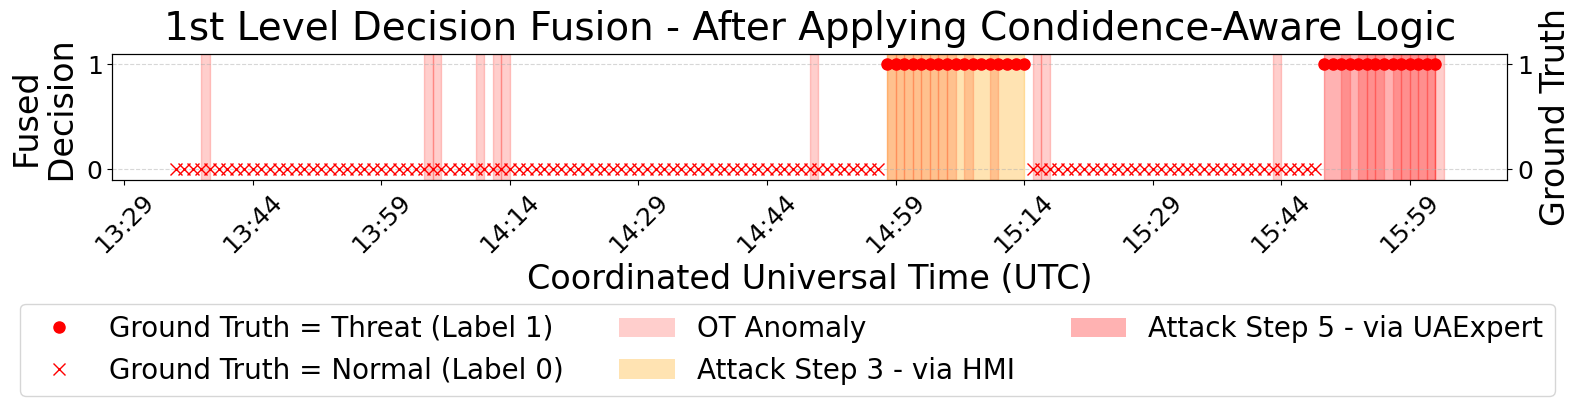

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator
from matplotlib.patches import Patch
import pandas as pd

# Ensure timestamp format is consistent
df_fusion['timestamp_bst'] = pd.to_datetime(df_fusion['timestamp_bst'])

# Define attack periods
attackviaHMI_start = pd.to_datetime("2025-05-09 15:58:00+01:00")
attackviaHMI_end   = pd.to_datetime("2025-05-09 16:14:00+01:00")
attackviaUA_start  = pd.to_datetime("2025-05-09 16:49:00+01:00")
attackviaUA_end    = pd.to_datetime("2025-05-09 17:02:00+01:00")

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(18, 2))

# === OT Anomalies (1-minute red bars)
ot_anomaly_added = False
for ts in df_fusion[df_fusion['final_binary_label'] == 1]['timestamp_bst']:
    ax1.axvspan(ts, ts + pd.Timedelta(minutes=1), color='#ff0c00', alpha=0.2,
                label='OT Anomaly' if not ot_anomaly_added else "")
    ot_anomaly_added = True

# === Highlight attack periods
ax1.axvspan(attackviaHMI_start, attackviaHMI_end, color='orange', alpha=0.3, label='Attack Step 3 - via HMI')
ax1.axvspan(attackviaUA_start, attackviaUA_end, color='red', alpha=0.3, label='Attack Step 5 - via UAExpert')

# === Configure primary axis
ax1.set_ylabel("Fused\n Decision", fontsize=24)
ax1.set_ylim(-0.1, 1.1)
ax1.set_yticks([0, 1])
ax1.set_xlabel("Coordinated Universal Time (UTC)", fontsize=24)
ax1.xaxis.set_major_locator(MinuteLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis='x', rotation=45, labelsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.grid(False, axis='x')

# === Ground Truth markers
ax2 = ax1.twinx()

# Ground Truth Anomaly (label=1): Red circle
gt_anomalies = df_fusion[df_fusion['GroundTruth_NetworkLabel'] == 1]
ax2.plot(gt_anomalies['timestamp_bst'], [1]*len(gt_anomalies),
         marker='o', linestyle='None', color='red', markersize=8, label='Ground Truth = Threat (Label 1)')

# Ground Truth Normal (label=0): Red X
gt_normal = df_fusion[df_fusion['GroundTruth_NetworkLabel'] == 0]
ax2.plot(gt_normal['timestamp_bst'], [0]*len(gt_normal),
         marker='x', linestyle='None', color='red', markersize=8, label='Ground Truth = Normal (Label 0)')

ax2.set_ylabel("Ground Truth", fontsize=24)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.tick_params(axis='y', labelsize=18)

# === Title
plt.title("1st Level Decision Fusion - After Applying Condidence-Aware Logic",
          fontsize=28, pad=10)

# === Legend
patches = [
    Patch(facecolor='#ff0c00', alpha=0.2, label='OT Anomaly'),
    Patch(facecolor='orange', alpha=0.3, label='Attack Step 3 - via HMI'),
    Patch(facecolor='red', alpha=0.3, label='Attack Step 5 - via UAExpert')
]

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
all_handles = lines2 + patches  # order: markers first, bars second
all_labels = labels2 + [p.get_label() for p in patches]

fig.legend(all_handles, all_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.9), ncol=3, fontsize=20)


# === Layout and export

plt.subplots_adjust(bottom=0.25)
plt.savefig("1stFusion_AfterConfidenceAwareLogicBarStyle.png", dpi=600, bbox_inches='tight')
plt.show()

To try next time

**Fusion logic successfully identified key anomalies during both HMI and UAExpert stages, with isolated false positives occurring outside the attack window. These are valuable for guiding deeper investigation.**

In [60]:
# Display full rows for the selected columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_fusion[['instance_x', 'timestamp_bst', 'Predicted_NetworkLabel',
                       'Predicted_ProcessLabel', 'decision_reason', 'final_binary_label', 'GroundTruth_NetworkLabel']])

,instance_x,timestamp_bst,Predicted_NetworkLabel,Predicted_ProcessLabel,decision_reason,final_binary_label,GroundTruth_NetworkLabel
0,1,2025-05-09 14:35:00+01:00,0,NaN,Case 1 (Only Network Data Available): Likely N...,0,0
1,2,2025-05-09 14:36:00+01:00,0,NaN,Case 1 (Only Network Data Available): Likely N...,0,0
2,3,2025-05-09 14:37:00+01:00,0,NaN,Case 1 (Only Network Data Available): Likely N...,0,0
3,4,2025-05-09 14:38:00+01:00,1,NaN,Case 1 (Only Network Data Available): Likely A...,1,0
4,5,2025-05-09 14:39:00+01:00,1,0.0,Case 3 (Predictions Conflicts): Normal - Proce...,0,0
5,6,2025-05-09 14:40:00+01:00,1,0.0,Case 3 (Predictions Conflicts): Normal - Proce...,0,0
6,7,2025-05-09 14:41:00+01:00,0,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,0
7,8,2025-05-09 14:42:00+01:00,0,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,0
8,9,2025-05-09 14:43:00+01:00,0,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,0
9,10,2025-05-09 14:44:00+01:00,0,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,0


In [61]:
df_fusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

In [62]:
df_fusion.to_csv('fusion_network_process_view_with_confidence_logic_final.csv', index=False)

from google.colab import files
files.download('fusion_network_process_view_with_confidence_logic_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Fusion logic corrected predictions originally misclassified by the process model alone — specifically by leveraging network anomaly scores.**

# 2nd Level Decision Fusion - IT / OT Fusion

## Step 1: Loading the list of host anomalies for preprocessing

In [63]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load Process Data with Anomaly Scores
df_host_full = pd.read_csv("host_anomaly_scores_full.csv")

Saving host_anomaly_scores_full.csv to host_anomaly_scores_full.csv


In [64]:
df_host_full

,timestamp_minute,anomaly_score,triggered_features,rationale_text
0,2025-05-09 11:13:00,2,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
1,2025-05-09 11:14:00,6,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
2,2025-05-09 11:15:00,14,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
3,2025-05-09 11:16:00,6,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
4,2025-05-09 11:18:00,2,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
...,...,...,...,...
226,2025-05-09 17:52:00,0,[],NaN
227,2025-05-09 17:53:00,0,[],NaN
228,2025-05-09 17:54:00,0,[],NaN
229,2025-05-09 17:55:00,0,[],NaN


Trimming of the host log is required because the host log captures all activity for from 11:13 am which is yet to be relevant to the simulated attack stage.

To match with the timeline with network data where it does not have any missing data, and it represents the starting time of the simulation for experimentation from the normal time, to attack step 1 to 5, and back to the normal stage.

In [65]:
import pandas as pd

# Convert host timestamp to datetime and ensure no timezone ambiguity
df_host_full['timestamp_minute'] = pd.to_datetime(df_host_full['timestamp_minute'])

# Define fusion time window (in UK local time, i.e. BST)
start_time = pd.to_datetime("2025-05-09 14:35:00")
end_time = pd.to_datetime("2025-05-09 17:56:00")

# Trim host dataframe within desired time range (follow the network log start time and end time to align the timing for this experimentation)
df_host_trim = df_host_full[(df_host_full['timestamp_minute'] >= start_time) &
                            (df_host_full['timestamp_minute'] <= end_time)].copy()

# Optional: Check trimming result
print(f"Trimmed host data from {df_host_trim['timestamp_minute'].min()} to {df_host_trim['timestamp_minute'].max()}")

Trimmed host data from 2025-05-09 14:35:00 to 2025-05-09 17:56:00


In [66]:
df_host_trim

,timestamp_minute,anomaly_score,triggered_features,rationale_text
99,2025-05-09 14:35:00,0,[],NaN
100,2025-05-09 14:36:00,0,[],NaN
101,2025-05-09 14:37:00,0,[],NaN
102,2025-05-09 14:40:00,0,[],NaN
103,2025-05-09 14:45:00,0,[],NaN
...,...,...,...,...
226,2025-05-09 17:52:00,0,[],NaN
227,2025-05-09 17:53:00,0,[],NaN
228,2025-05-09 17:54:00,0,[],NaN
229,2025-05-09 17:55:00,0,[],NaN


In [67]:
df_host_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp_minute    231 non-null    datetime64[ns]
 1   anomaly_score       231 non-null    int64         
 2   triggered_features  231 non-null    object        
 3   rationale_text      102 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.3+ KB


In [68]:
df_host_trim['timestamp_minute'] = df_host_trim['timestamp_minute'].dt.tz_localize('Europe/London')

In [69]:
df_fusion.rename(columns={'timestamp_bst': 'timestamp_minute'}, inplace=True)

In [70]:
df_host_trim.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 99 to 230
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype                        
---  ------              --------------  -----                        
 0   timestamp_minute    132 non-null    datetime64[ns, Europe/London]
 1   anomaly_score       132 non-null    int64                        
 2   triggered_features  132 non-null    object                       
 3   rationale_text      67 non-null     object                       
dtypes: datetime64[ns, Europe/London](1), int64(1), object(2)
memory usage: 5.2+ KB


In [71]:
df_host_trim

,timestamp_minute,anomaly_score,triggered_features,rationale_text
99,2025-05-09 14:35:00+01:00,0,[],NaN
100,2025-05-09 14:36:00+01:00,0,[],NaN
101,2025-05-09 14:37:00+01:00,0,[],NaN
102,2025-05-09 14:40:00+01:00,0,[],NaN
103,2025-05-09 14:45:00+01:00,0,[],NaN
...,...,...,...,...
226,2025-05-09 17:52:00+01:00,0,[],NaN
227,2025-05-09 17:53:00+01:00,0,[],NaN
228,2025-05-09 17:54:00+01:00,0,[],NaN
229,2025-05-09 17:55:00+01:00,0,[],NaN


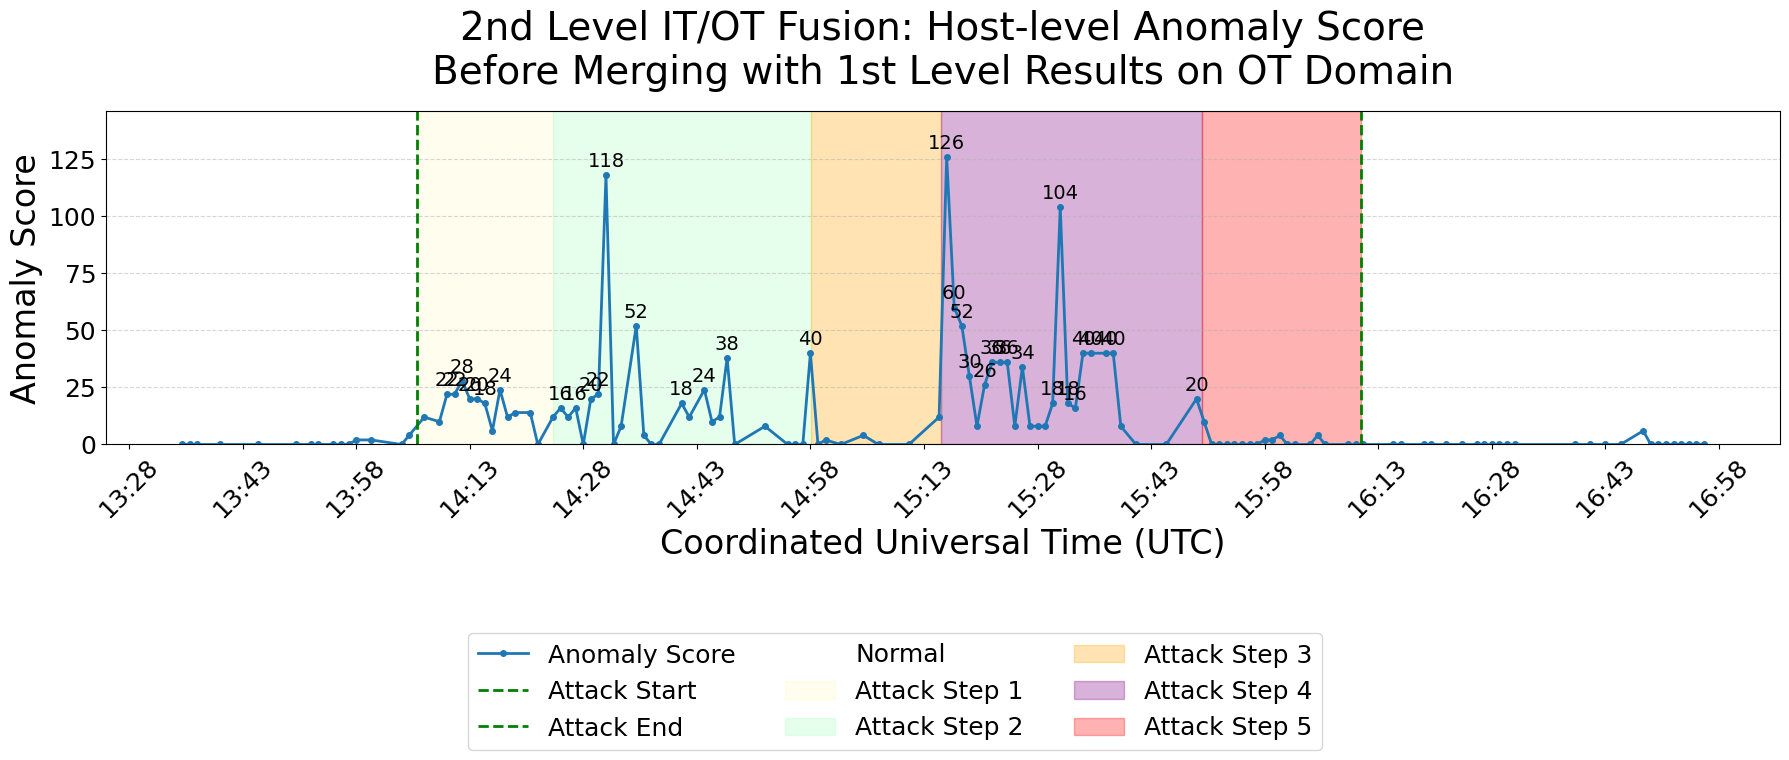

In [72]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator
import pandas as pd

# === Define Attack Step Times in UTC===
step_times = [
    pd.to_datetime("2025-05-09 14:35:00+01:00"), # Normal
    pd.to_datetime("2025-05-09 15:06:00+01:00"), # Step 1
    pd.to_datetime("2025-05-09 15:24:00+01:00"), # Step 2
    pd.to_datetime("2025-05-09 15:58:05+01:00"), # Step 3
    pd.to_datetime("2025-05-09 16:15:18+01:00"), # Step 4
    pd.to_datetime("2025-05-09 16:49:47+01:00"), # Step 5
    pd.to_datetime("2025-05-09 17:10:43+01:00")  # Normal
]

step_labels = ['Normal','Attack Step 1', 'Attack Step 2', 'Attack Step 3', 'Attack Step 4', 'Attack Step 5','Normal']

# === Step Colors ===
step_colors = ['white',    # Normal
               '#fffac8',  # Step 1 - light yellow
               '#aaffc3',  # Step 2 - light green
               'orange',   # Step 3 - orange
               'purple',   # Step 4 - light blue
               'red',      # Step 5 - red
               'white'     # Normal
]

# === Plot Host Anomaly Score ===
fig, ax = plt.subplots(figsize=(18, 6))

# Plot anomaly score
ax.plot(df_host_trim['timestamp_minute'], df_host_trim['anomaly_score'],
        color='#1f77b4', linewidth=2.0, marker='o', markersize=4, label='Anomaly Score')

# Annotate anomaly score values
for x, y in zip(df_host_trim['timestamp_minute'], df_host_trim['anomaly_score']):
    if y > 15:  # Only label with score above 15 for decluttering
        ax.text(x, y + 2, str(y), fontsize=14, ha='center', va='bottom', color='black')

# Add shaded attack zones
added_labels = set()
for i in range(len(step_times) - 1):
    label = step_labels[i]
    color = step_colors[i]
    label_to_add = label if label not in added_labels else None
    ax.axvspan(step_times[i], step_times[i + 1], color=color, alpha=0.3, label=label_to_add)
    added_labels.add(label)

# Vertical green dashed line for start and end time of multi-stage attack
ax.axvline(step_times[1], color='green', linestyle='--', linewidth=2, label='Attack Start')
ax.axvline(step_times[-1], color='green', linestyle='--', linewidth=2, label='Attack End')

# Format X-axis
ax.set_xlabel("Coordinated Universal Time (UTC)", fontsize=24)
ax.set_ylabel("Anomaly Score", fontsize=24)
ax.set_ylim(0, df_host_trim['anomaly_score'].max() + 20)
ax.xaxis.set_major_locator(MinuteLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Title
ax.set_title("2nd Level IT/OT Fusion: Host-level Anomaly Score\nBefore Merging with 1st Level Results on OT Domain",
             fontsize=28, pad=20)

# Legend
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))
ordered_labels = ['Anomaly Score', 'Attack Start', 'Attack End', 'Normal',
                  'Attack Step 1', 'Attack Step 2', 'Attack Step 3',
                  'Attack Step 4', 'Attack Step 5']

ordered_handles = [legend_dict[label] for label in ordered_labels if label in legend_dict]

fig.legend(ordered_handles, ordered_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=18)

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig("2ndFusion_View_Before_Merging1stFusion.png", dpi=600, bbox_inches='tight')
plt.show()

##Step 2: Merge and normalize

In [73]:
df_fusion_2nd = pd.merge(df_fusion, df_host_trim,
                         on='timestamp_minute',
                         how='left')

In [74]:
df_fusion_2nd

,instance_x,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,timestamp,...,process_score,Process_Label_3Class,GroundTruth_ProcessLabel,Predicted_ProcessLabel,final_fused_label,decision_reason,final_binary_label,anomaly_score_y,triggered_features,rationale_text
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,NaN,...,NaN,NaN,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,2025-05-09 13:38:00,...,NaN,NaN,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely A...,1,NaN,NaN,NaN
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,2025-05-09 13:39:00,...,0.0000,Process - Normal,0.0,0.0,0.0,Case 3 (Predictions Conflicts): Normal - Proce...,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,2025-05-09 15:58:00,...,0.9978,Process - Anomaly,1.0,1.0,1.0,Case 3 (Predictions Aligned): Anomaly - Proces...,1,2.0,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,2025-05-09 15:59:00,...,0.9942,Process - Anomaly,1.0,1.0,1.0,Case 3 (Predictions Aligned): Anomaly - Proces...,1,2.0,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,2025-05-09 16:00:00,...,0.9984,Process - Anomaly,1.0,1.0,4.0,Case 3 (Predictions Aligned): Anomaly - Proces...,1,4.0,"['anomaly_medium_or_higher', 'anomaly_score']",Wazuh rule level 7 or above (medium/high sever...
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,2025-05-09 16:01:00,...,0.9135,Process - Anomaly,1.0,1.0,4.0,Case 3 (Predictions Aligned): Anomaly - Proces...,1,0.0,[],NaN


In [75]:
df_fusion_2nd.to_csv('fusion_network_process_host_view.csv', index=False)

from google.colab import files
files.download('fusion_network_process_host_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
df_fusion_2nd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

In [77]:
# Display rows for the selected columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_fusion_2nd[['timestamp_minute', 'alarm_count', 'instance_x', 'anomaly_score_x', 'Label_Description',
          'final_fused_label', 'decision_reason', 'final_binary_label', 'anomaly_score_y',
                           'triggered_features', 'rationale_text', 'GroundTruth_NetworkLabel','node_ids_written']])

,timestamp_minute,alarm_count,instance_x,anomaly_score_x,Label_Description,final_fused_label,decision_reason,final_binary_label,anomaly_score_y,triggered_features,rationale_text,GroundTruth_NetworkLabel,node_ids_written
0,2025-05-09 14:35:00+01:00,NaN,1,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN,0,NaN
1,2025-05-09 14:36:00+01:00,NaN,2,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN,0,NaN
2,2025-05-09 14:37:00+01:00,NaN,3,NaN,NaN,0.0,Case 1 (Only Network Data Available): Likely N...,0,0.0,[],NaN,0,NaN
3,2025-05-09 14:38:00+01:00,NaN,4,-0.087744,NaN,0.0,Case 1 (Only Network Data Available): Likely A...,1,NaN,NaN,NaN,0,-
4,2025-05-09 14:39:00+01:00,0.0,5,-0.139128,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Conflicts): Normal - Proce...,0,NaN,NaN,NaN,0,-
5,2025-05-09 14:40:00+01:00,0.0,6,-0.139128,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Conflicts): Normal - Proce...,0,0.0,[],NaN,0,-
6,2025-05-09 14:41:00+01:00,0.0,7,NaN,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,NaN,NaN,NaN,0,NaN
7,2025-05-09 14:42:00+01:00,0.0,8,NaN,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,NaN,NaN,NaN,0,NaN
8,2025-05-09 14:43:00+01:00,0.0,9,NaN,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,NaN,NaN,NaN,0,NaN
9,2025-05-09 14:44:00+01:00,0.0,10,NaN,Label 0: Normal_NoIntervention,0.0,Case 3 (Predictions Aligned): Normal - No Conf...,0,NaN,NaN,NaN,0,NaN


## Step 3: Visualisation of 2nd Level Decision Fusion

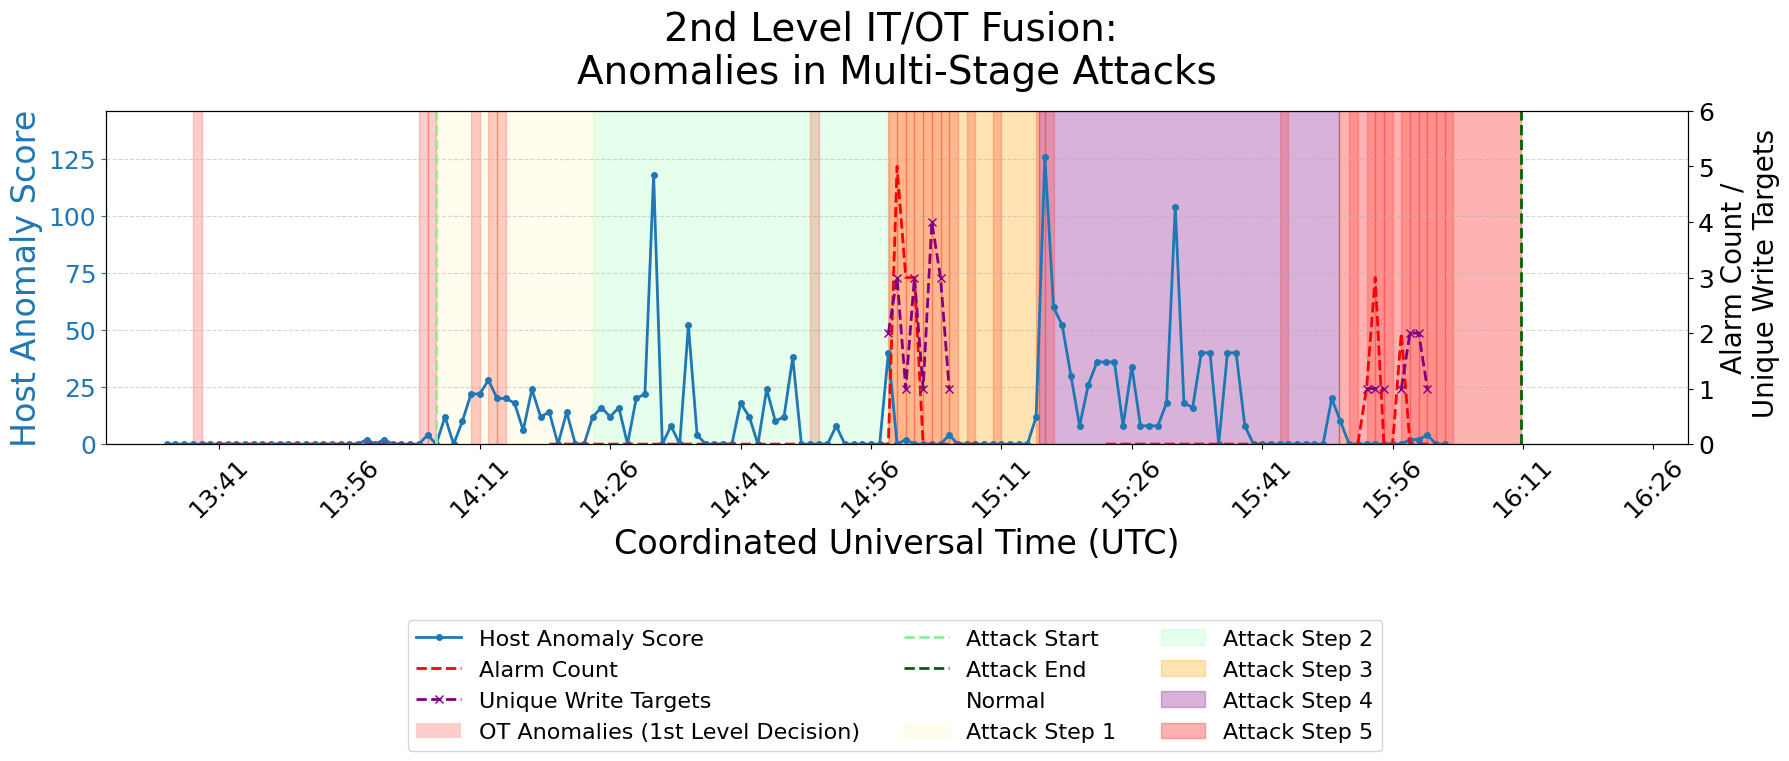

In [78]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator
import pandas as pd
from matplotlib.patches import Patch
# === Define Attack Step Times (UTC+1) ===
step_times = [
    pd.to_datetime("2025-05-09 14:35:00+01:00"),
    pd.to_datetime("2025-05-09 15:06:00+01:00"),
    pd.to_datetime("2025-05-09 15:24:00+01:00"),
    pd.to_datetime("2025-05-09 15:58:05+01:00"),
    pd.to_datetime("2025-05-09 16:15:18+01:00"),
    pd.to_datetime("2025-05-09 16:49:47+01:00"),
    pd.to_datetime("2025-05-09 17:10:43+01:00")
]

step_labels = ['Normal', 'Attack Step 1', 'Attack Step 2', 'Attack Step 3', 'Attack Step 4', 'Attack Step 5', 'Normal']
step_colors = ['white', '#fffac8', '#aaffc3', 'orange', 'purple', 'red', 'white']

# === Create Plot ===
fig, ax1 = plt.subplots(figsize=(18, 6))

# Fill in NaN with 0 for continuity
df_fusion_2nd['anomaly_score_y_filled'] = df_fusion_2nd['anomaly_score_y'].fillna(0)

# Plot Host Anomaly Score
ax1.plot(df_fusion_2nd['timestamp_minute'], df_fusion_2nd['anomaly_score_y_filled'],
         color='#1f77b4', linewidth=2.0, marker='o', markersize=4,
         label='Host Anomaly Score')

# Shaded Attack Zones
added_labels = set()
for i in range(len(step_times) - 1):
    label = step_labels[i]
    color = step_colors[i]
    label_to_add = label if label not in added_labels else None
    ax1.axvspan(step_times[i], step_times[i + 1], color=color, alpha=0.3, label=label_to_add)
    added_labels.add(label)

# Attack Start/End
ax1.axvline(step_times[1], color='lightgreen', linestyle='--', linewidth=2, label='Attack Start')
ax1.axvline(step_times[-1], color='darkgreen', linestyle='--', linewidth=2, label='Attack End')

# Left Axis Formatting
ax1.set_xlabel("Coordinated Universal Time (UTC)", fontsize=24)
ax1.set_ylabel("Host Anomaly Score", fontsize=24, color='#1f77b4')
ax1.set_ylim(0, df_fusion_2nd['anomaly_score_y_filled'].max() + 20)
ax1.set_xlim(pd.to_datetime("2025-05-09 14:28:00+01:00"), pd.to_datetime("2025-05-09 17:30:00+01:00"))
ax1.xaxis.set_major_locator(MinuteLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis='x', rotation=45, labelsize=18)
ax1.tick_params(axis='y', labelsize=18, colors='#1f77b4')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

# === Right Y-axis ===
ax2 = ax1.twinx()

# Final Binary Label = 1 at fixed height 40
df_fused_1 = df_fusion_2nd[df_fusion_2nd['final_binary_label'] == 1]
for timestamp in df_fused_1['timestamp_minute']:
    ax1.axvspan(timestamp, timestamp + pd.Timedelta(minutes=1),
                color='#ff0c00', alpha=0.2, label='1st-Level OT Fused Result = Anomaly' if '1st-Level OT Fused Result = Anomaly' not in added_labels else "")
    added_labels.add('1st-Level OT Fused Result = Anomaly')

# Alarm Count (original scale)
if 'alarm_count' in df_fusion_2nd.columns:
    ax2.plot(df_fusion_2nd['timestamp_minute'], df_fusion_2nd['alarm_count'],
             linestyle='--', linewidth=2.0, color='red',
             label='Alarm Count')

# Unique Write Targets (original scale)
if 'unique_write_targets_count' in df_fusion_2nd.columns:
    ax2.plot(df_fusion_2nd['timestamp_minute'], df_fusion_2nd['unique_write_targets_count'],
             linestyle='--', linewidth=2.0, color='purple', marker='x',
             label='Unique Write Targets')

# Right Axis Formatting
ax2.set_ylabel("Alarm Count /\n Unique Write Targets", fontsize=20, color='black')
right_y_max = max(
    df_fusion_2nd['alarm_count'].max() if 'alarm_count' in df_fusion_2nd else 0,
    df_fusion_2nd['unique_write_targets_count'].max() if 'unique_write_targets_count' in df_fusion_2nd else 0,
)

ax2.set_ylim(0, max(right_y_max, 6))
ax2.tick_params(axis='y', labelsize=18)

for label in ax2.get_yticklabels():
    label.set_color('black')

# === Title and Legend ===
plt.title("2nd Level IT/OT Fusion: \nAnomalies in Multi-Stage Attacks",
          fontsize=28, pad=20)


# Manual patch for OT Anomaly bar
ot_anomaly_patch = Patch(facecolor='#ff0c00', alpha=0.2, label='OT Anomalies (1st Level Decision)')

# Collect all legend entries
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend_dict = dict(zip(labels1 + labels2, lines1 + lines2))
legend_dict['OT Anomalies (1st Level Decision)'] = ot_anomaly_patch  # add patch manually

# Specify legend display order
ordered_labels = [
    'Host Anomaly Score',
    'Alarm Count', 'Unique Write Targets',
    'OT Anomalies (1st Level Decision)',
    'Attack Start', 'Attack End',
    'Normal', 'Attack Step 1', 'Attack Step 2', 'Attack Step 3',
    'Attack Step 4', 'Attack Step 5'
]
ordered_handles = [legend_dict[label] for label in ordered_labels if label in legend_dict]

# Add the cleaned legend
fig.legend(ordered_handles, ordered_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=16)

# Final layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.savefig("2ndITOTFusionFinalResult.png", dpi=600, bbox_inches='tight')
plt.show()

In [79]:
df_fusion_2nd.to_csv('fusion_network_process_host_view_final.csv', index=False)

from google.colab import files
files.download('fusion_network_process_host_view_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 4: Threat Log for Investigation

In [80]:
df_fusion_2nd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype                        
---  ------                      --------------  -----                        
 0   instance_x                  148 non-null    int64                        
 1   write_anomaly_count         148 non-null    int64                        
 2   write_anomaly_ratio         148 non-null    float64                      
 3   write_ops_count             148 non-null    int64                        
 4   write_ops_ratio             148 non-null    float64                      
 5   total_packets               148 non-null    int64                        
 6   unique_write_targets_count  15 non-null     float64                      
 7   Network_Anomaly_Score       148 non-null    float64                      
 8   Network_Predicted_Label     148 non-null    int64                        
 9   timestamp            

In [99]:
import pandas as pd
from io import StringIO

def export_fused_anomaly_log(df, filename="anomaly_log.txt"):
    buffer = StringIO()

    for _, row in df.iterrows():
        ts = str(row['timestamp_minute'])  # BST timestamp string

        is_fused_anomaly = row.get('final_binary_label', 0) == 1
        is_host_anomaly = row.get('anomaly_score_y_filled', 0) > 0

        if is_fused_anomaly or is_host_anomaly:
            buffer.write(f"\nTime {ts} (BST)\n")

            if is_fused_anomaly:
                buffer.write("→ [OT Network and Process] Anomaly Detected\n")
                buffer.write(f"  Reason: {row.get('decision_reason', 'N/A')}\n")
                buffer.write(f"  - Network Anomaly Score: {row.get('Network_Anomaly_Score', 'N/A'):.3f}\n")
                if pd.notna(row.get('unique_write_targets_count')):
                    buffer.write(f"  - Unique Write Targets: {int(row['unique_write_targets_count'])}\n")
                if pd.notna(row.get('node_ids_written')) and row['node_ids_written'] not in ['-', '']:
                    buffer.write(f"  - Node IDs Written: {row['node_ids_written']}\n")
                if pd.notna(row.get('message_sizes')) and row['message_sizes'] not in ['-', '']:
                    buffer.write(f"  - OPC UA Message Sizes: {row['message_sizes']}\n")
                if row.get('alarm_count', 0) > 0:
                    buffer.write(f"  - Process Alarms: {int(row['alarm_count'])}\n")
                if pd.notna(row.get('Process_Predicted_Label')):
                    buffer.write(f"  - Process Prediction: Class {int(row['Process_Predicted_Label'])}\n")
                    probs = [f"Class {i}: {row.get(f'Prob_Class_{i}', 0):.1%}" for i in range(5)]
                    buffer.write(f"    Class Probabilities: {' | '.join(probs)}\n")

            if is_host_anomaly:
                buffer.write("→ [Host] Anomaly Detected\n")
                buffer.write(f"  - Host Anomaly Score: {int(row['anomaly_score_y_filled'])}\n")
                if pd.notna(row.get('triggered_features')):
                    buffer.write(f"  - Triggered Features: {row['triggered_features']}\n")
                if pd.notna(row.get('rationale_text')):
                    buffer.write(f"  - Explanation: {row['rationale_text']}\n")

            buffer.write("-" * 60 + "\n")

    # Save to file
    with open(filename, "w", encoding="utf-8") as f:
        f.write(buffer.getvalue())

    # Optionally, print output to console
    print(buffer.getvalue())

    # Return the raw text in case you want to preview it programmatically
    return buffer.getvalue()

In [100]:
export_fused_anomaly_log(df_fusion_2nd, "fusion_anomaly_log_09May.txt")


Time 2025-05-09 14:38:00+01:00 (BST)
→ [OT Network and Process] Anomaly Detected
  Reason: Case 1 (Only Network Data Available): Likely Anomaly
  - Network Anomaly Score: -0.088
  - OPC UA Message Sizes: 253, 100, 204, 189, 1584
------------------------------------------------------------

Time 2025-05-09 14:58:00+01:00 (BST)
→ [Host] Anomaly Detected
  - Host Anomaly Score: 2
  - Triggered Features: ['anomaly_medium_or_higher', 'anomaly_score']
  - Explanation: Wazuh rule level 7 or above (medium/high severity)
------------------------------------------------------------

Time 2025-05-09 15:00:00+01:00 (BST)
→ [Host] Anomaly Detected
  - Host Anomaly Score: 2
  - Triggered Features: ['anomaly_medium_or_higher', 'anomaly_score']
  - Explanation: Wazuh rule level 7 or above (medium/high severity)
------------------------------------------------------------

Time 2025-05-09 15:04:00+01:00 (BST)
→ [OT Network and Process] Anomaly Detected
  Reason: Case 1 (Only Network Data Available): L

"\nTime 2025-05-09 14:38:00+01:00 (BST)\n→ [OT Network and Process] Anomaly Detected\n  Reason: Case 1 (Only Network Data Available): Likely Anomaly\n  - Network Anomaly Score: -0.088\n  - OPC UA Message Sizes: 253, 100, 204, 189, 1584\n------------------------------------------------------------\n\nTime 2025-05-09 14:58:00+01:00 (BST)\n→ [Host] Anomaly Detected\n  - Host Anomaly Score: 2\n  - Triggered Features: ['anomaly_medium_or_higher', 'anomaly_score']\n  - Explanation: Wazuh rule level 7 or above (medium/high severity)\n------------------------------------------------------------\n\nTime 2025-05-09 15:00:00+01:00 (BST)\n→ [Host] Anomaly Detected\n  - Host Anomaly Score: 2\n  - Triggered Features: ['anomaly_medium_or_higher', 'anomaly_score']\n  - Explanation: Wazuh rule level 7 or above (medium/high severity)\n------------------------------------------------------------\n\nTime 2025-05-09 15:04:00+01:00 (BST)\n→ [OT Network and Process] Anomaly Detected\n  Reason: Case 1 (Only N

The End